## Word Overlap in SCAR dataset

In [25]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Import NLTK for stopwords
try:
    import nltk
    try:
        from nltk.corpus import stopwords
        # Download stopwords if not already downloaded
        try:
            stopwords.words('english')
        except LookupError:
            nltk.download('stopwords', quiet=True)
        FILLER_WORDS = set(stopwords.words('english'))
        print(f"✅ Loaded {len(FILLER_WORDS)} stopwords from NLTK")
    except ImportError:
        print("⚠️ NLTK not available. Using fallback stopwords list.")
        # Fallback to a basic list if NLTK is not available
        FILLER_WORDS = {
            'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by',
            'from', 'as', 'is', 'was', 'are', 'were', 'been', 'be', 'have', 'has', 'had', 'do', 'does', 'did',
            'will', 'would', 'could', 'should', 'may', 'might', 'must', 'can', 'this', 'that', 'these', 'those',
            'i', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them',
            'my', 'your', 'his', 'her', 'its', 'our', 'their', 'mine', 'yours', 'hers', 'ours', 'theirs',
            'what', 'which', 'who', 'whom', 'whose', 'where', 'when', 'why', 'how',
            'all', 'each', 'every', 'both', 'few', 'many', 'most', 'other', 'some', 'such', 'no', 'nor', 'not',
            'only', 'own', 'same', 'so', 'than', 'too', 'very', 'just', 'now'
        }
except ImportError:
    print("⚠️ NLTK not installed. Install with: pip install nltk")
    print("Using fallback stopwords list.")
    # Fallback to a basic list if NLTK is not available
    FILLER_WORDS = {
        'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by',
        'from', 'as', 'is', 'was', 'are', 'were', 'been', 'be', 'have', 'has', 'had', 'do', 'does', 'did',
        'will', 'would', 'could', 'should', 'may', 'might', 'must', 'can', 'this', 'that', 'these', 'those',
        'i', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them',
        'my', 'your', 'his', 'her', 'its', 'our', 'their', 'mine', 'yours', 'hers', 'ours', 'theirs',
        'what', 'which', 'who', 'whom', 'whose', 'where', 'when', 'why', 'how',
        'all', 'each', 'every', 'both', 'few', 'many', 'most', 'other', 'some', 'such', 'no', 'nor', 'not',
        'only', 'own', 'same', 'so', 'than', 'too', 'very', 'just', 'now'
    }

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load SCAR dataset
df_scar = pd.read_csv('../../data/SCAR_cleaned_manually.csv')

print(f"Loaded SCAR dataset: {len(df_scar)} analogies")
print(f"Unique targets (system_a): {df_scar['system_a'].nunique()}")
print(f"Unique sources (system_b): {df_scar['system_b'].nunique()}")
print(f"\nColumns: {list(df_scar.columns)}")


✅ Loaded 198 stopwords from NLTK
Loaded SCAR dataset: 400 analogies
Unique targets (system_a): 321
Unique sources (system_b): 333

Columns: ['id', 'system_a', 'system_b', 'system_a_domain', 'system_b_domain', 'system_a_background', 'system_b_background', 'mappings_parsed', 'mapping_count', 'explanation_parsed', 'explanation_count', 'system_a_bg_wc', 'system_b_bg_wc']


## Word Overlap Functions


In [26]:
# Use NLTK stopwords (should be loaded in Cell 1, but load here if needed)
try:
    # Try to use FILLER_WORDS from Cell 1
    _ = len(FILLER_WORDS)  # Check if it exists
    print(f"✅ Using FILLER_WORDS from previous cell ({len(FILLER_WORDS)} words)")
except NameError:
    # If not available, load from NLTK
    try:
        import nltk
        from nltk.corpus import stopwords
        # Download stopwords if not already downloaded
        try:
            stopwords.words('english')
        except LookupError:
            nltk.download('stopwords', quiet=True)
        FILLER_WORDS = set(stopwords.words('english'))
        print(f"✅ Loaded {len(FILLER_WORDS)} stopwords from NLTK")
    except ImportError:
        print("⚠️ NLTK not available. Install with: pip install nltk")
        print("Using minimal fallback stopwords list.")
        # Minimal fallback list
        FILLER_WORDS = {
            'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by',
            'from', 'as', 'is', 'was', 'are', 'were', 'been', 'be', 'have', 'has', 'had', 'do', 'does', 'did',
            'will', 'would', 'could', 'should', 'may', 'might', 'must', 'can', 'this', 'that', 'these', 'those',
            'i', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them',
            'my', 'your', 'his', 'her', 'its', 'our', 'their', 'mine', 'yours', 'hers', 'ours', 'theirs',
            'what', 'which', 'who', 'whom', 'whose', 'where', 'when', 'why', 'how',
            'all', 'each', 'every', 'both', 'few', 'many', 'most', 'other', 'some', 'such', 'no', 'nor', 'not',
            'only', 'own', 'same', 'so', 'than', 'too', 'very', 'just', 'now'
        }

def tokenize_text(text):
    """
    Tokenize text into words (lowercase, remove punctuation, split into words)
    
    Args:
        text: Input text string
        
    Returns:
        Set of unique words
    """
    if pd.isna(text) or text == '':
        return set()
    
    # Convert to string, lowercase, remove punctuation, split into words
    text = str(text).lower()
    # Remove punctuation and split by whitespace
    words = re.findall(r'\b\w+\b', text)
    return set(words)


def calculate_word_overlap(text1, text2):
    """
    Calculate word overlap between two texts, separating filler words from meaningful words
    
    Args:
        text1: First text string
        text2: Second text string
        
    Returns:
        dict with:
        - overlap_count: Number of overlapping words (total)
        - overlapping_words: Set of overlapping words
        - filler_overlap_count: Number of overlapping filler words
        - filler_overlapping_words: Set of overlapping filler words
        - meaningful_overlap_count: Number of overlapping meaningful words
        - meaningful_overlapping_words: Set of overlapping meaningful words
        - filler_overlap_percentage: Percentage of overlap that are fillers
        - meaningful_overlap_percentage: Percentage of overlap that are meaningful
        - words1: Set of words in text1
        - words2: Set of words in text2
        - jaccard_similarity: Jaccard similarity coefficient
    """
    words1 = tokenize_text(text1)
    words2 = tokenize_text(text2)
    
    overlapping_words = words1.intersection(words2)
    overlap_count = len(overlapping_words)
    
    # Separate filler words from meaningful words
    filler_overlapping_words = overlapping_words.intersection(FILLER_WORDS)
    meaningful_overlapping_words = overlapping_words - filler_overlapping_words
    
    filler_overlap_count = len(filler_overlapping_words)
    meaningful_overlap_count = len(meaningful_overlapping_words)
    
    # Calculate percentages
    filler_overlap_percentage = (filler_overlap_count / overlap_count * 100) if overlap_count > 0 else 0.0
    meaningful_overlap_percentage = (meaningful_overlap_count / overlap_count * 100) if overlap_count > 0 else 0.0
    
    # Calculate Jaccard similarity
    union_words = words1.union(words2)
    jaccard_similarity = len(overlapping_words) / len(union_words) if len(union_words) > 0 else 0.0
    
    return {
        'overlap_count': overlap_count,
        'overlapping_words': overlapping_words,
        'filler_overlap_count': filler_overlap_count,
        'filler_overlapping_words': filler_overlapping_words,
        'meaningful_overlap_count': meaningful_overlap_count,
        'meaningful_overlapping_words': meaningful_overlapping_words,
        'filler_overlap_percentage': filler_overlap_percentage,
        'meaningful_overlap_percentage': meaningful_overlap_percentage,
        'words1': words1,
        'words2': words2,
        'jaccard_similarity': jaccard_similarity
    }


def calculate_overlap_for_row(row):
    """
    Calculate word overlap for a single row (source vs target)
    
    Args:
        row: DataFrame row with system_a and system_b columns
        
    Returns:
        dict with overlap metrics including filler word analysis
    """
    # Calculate overlap for names
    name_overlap = calculate_word_overlap(row['system_a'], row['system_b'])
    
    # Calculate overlap for backgrounds (if available)
    bg_overlap = None
    if 'system_a_background' in row and 'system_b_background' in row:
        bg_overlap = calculate_word_overlap(row['system_a_background'], row['system_b_background'])
    
    result = {
        'name_overlap_count': name_overlap['overlap_count'],
        'name_overlapping_words': name_overlap['overlapping_words'],
        'name_filler_overlap_count': name_overlap['filler_overlap_count'],
        'name_filler_overlapping_words': name_overlap['filler_overlapping_words'],
        'name_meaningful_overlap_count': name_overlap['meaningful_overlap_count'],
        'name_meaningful_overlapping_words': name_overlap['meaningful_overlapping_words'],
        'name_filler_overlap_percentage': name_overlap['filler_overlap_percentage'],
        'name_meaningful_overlap_percentage': name_overlap['meaningful_overlap_percentage'],
        'name_jaccard': name_overlap['jaccard_similarity'],
    }
    
    if bg_overlap:
        result.update({
            'bg_overlap_count': bg_overlap['overlap_count'],
            'bg_overlapping_words': bg_overlap['overlapping_words'],
            'bg_filler_overlap_count': bg_overlap['filler_overlap_count'],
            'bg_filler_overlapping_words': bg_overlap['filler_overlapping_words'],
            'bg_meaningful_overlap_count': bg_overlap['meaningful_overlap_count'],
            'bg_meaningful_overlapping_words': bg_overlap['meaningful_overlapping_words'],
            'bg_filler_overlap_percentage': bg_overlap['filler_overlap_percentage'],
            'bg_meaningful_overlap_percentage': bg_overlap['meaningful_overlap_percentage'],
            'bg_jaccard': bg_overlap['jaccard_similarity'],
        })
    else:
        result.update({
            'bg_overlap_count': None,
            'bg_overlapping_words': None,
            'bg_filler_overlap_count': None,
            'bg_filler_overlapping_words': None,
            'bg_meaningful_overlap_count': None,
            'bg_meaningful_overlapping_words': None,
            'bg_filler_overlap_percentage': None,
            'bg_meaningful_overlap_percentage': None,
            'bg_jaccard': None,
        })
    
    return result


✅ Using FILLER_WORDS from previous cell (198 words)


## Calculate Word Overlap for All Pairs


In [27]:
# Calculate word overlap for all pairs
print("Calculating word overlap for all source-target pairs...")

# Apply overlap calculation to each row
overlap_results = df_scar.apply(calculate_overlap_for_row, axis=1)

# Convert results to DataFrame columns - Names
df_scar['name_overlap_count'] = overlap_results.apply(lambda x: x['name_overlap_count'])
df_scar['name_overlapping_words'] = overlap_results.apply(lambda x: x['name_overlapping_words'])
df_scar['name_filler_overlap_count'] = overlap_results.apply(lambda x: x['name_filler_overlap_count'])
df_scar['name_filler_overlapping_words'] = overlap_results.apply(lambda x: x['name_filler_overlapping_words'])
df_scar['name_meaningful_overlap_count'] = overlap_results.apply(lambda x: x['name_meaningful_overlap_count'])
df_scar['name_meaningful_overlapping_words'] = overlap_results.apply(lambda x: x['name_meaningful_overlapping_words'])
df_scar['name_filler_overlap_percentage'] = overlap_results.apply(lambda x: x['name_filler_overlap_percentage'])
df_scar['name_meaningful_overlap_percentage'] = overlap_results.apply(lambda x: x['name_meaningful_overlap_percentage'])
df_scar['name_jaccard'] = overlap_results.apply(lambda x: x['name_jaccard'])

# Convert results to DataFrame columns - Backgrounds (if available)
if overlap_results.iloc[0]['bg_overlap_count'] is not None:
    df_scar['bg_overlap_count'] = overlap_results.apply(lambda x: x['bg_overlap_count'])
    df_scar['bg_overlapping_words'] = overlap_results.apply(lambda x: x['bg_overlapping_words'])
    df_scar['bg_filler_overlap_count'] = overlap_results.apply(lambda x: x['bg_filler_overlap_count'])
    df_scar['bg_filler_overlapping_words'] = overlap_results.apply(lambda x: x['bg_filler_overlapping_words'])
    df_scar['bg_meaningful_overlap_count'] = overlap_results.apply(lambda x: x['bg_meaningful_overlap_count'])
    df_scar['bg_meaningful_overlapping_words'] = overlap_results.apply(lambda x: x['bg_meaningful_overlapping_words'])
    df_scar['bg_filler_overlap_percentage'] = overlap_results.apply(lambda x: x['bg_filler_overlap_percentage'])
    df_scar['bg_meaningful_overlap_percentage'] = overlap_results.apply(lambda x: x['bg_meaningful_overlap_percentage'])
    df_scar['bg_jaccard'] = overlap_results.apply(lambda x: x['bg_jaccard'])

print(f"✅ Calculated overlap for {len(df_scar)} pairs")
print(f"\nSummary Statistics (Names):")
print(f"Total Overlap - Mean: {df_scar['name_overlap_count'].mean():.2f}, "
      f"Median: {df_scar['name_overlap_count'].median():.2f}, "
      f"Max: {df_scar['name_overlap_count'].max()}, "
      f"Min: {df_scar['name_overlap_count'].min()}")
print(f"Meaningful Overlap - Mean: {df_scar['name_meaningful_overlap_count'].mean():.2f}, "
      f"Median: {df_scar['name_meaningful_overlap_count'].median():.2f}, "
      f"Max: {df_scar['name_meaningful_overlap_count'].max()}, "
      f"Min: {df_scar['name_meaningful_overlap_count'].min()}")
print(f"Filler Overlap - Mean: {df_scar['name_filler_overlap_count'].mean():.2f}, "
      f"Median: {df_scar['name_filler_overlap_count'].median():.2f}, "
      f"Max: {df_scar['name_filler_overlap_count'].max()}, "
      f"Min: {df_scar['name_filler_overlap_count'].min()}")
print(f"Mean Filler Percentage: {df_scar['name_filler_overlap_percentage'].mean():.1f}%")
print(f"Mean Meaningful Percentage: {df_scar['name_meaningful_overlap_percentage'].mean():.1f}%")

if 'bg_overlap_count' in df_scar.columns:
    print(f"\nSummary Statistics (Backgrounds):")
    print(f"Total Overlap - Mean: {df_scar['bg_overlap_count'].mean():.2f}, "
          f"Median: {df_scar['bg_overlap_count'].median():.2f}, "
          f"Max: {df_scar['bg_overlap_count'].max()}, "
          f"Min: {df_scar['bg_overlap_count'].min()}")
    print(f"Meaningful Overlap - Mean: {df_scar['bg_meaningful_overlap_count'].mean():.2f}, "
          f"Median: {df_scar['bg_meaningful_overlap_count'].median():.2f}, "
          f"Max: {df_scar['bg_meaningful_overlap_count'].max()}, "
          f"Min: {df_scar['bg_meaningful_overlap_count'].min()}")
    print(f"Filler Overlap - Mean: {df_scar['bg_filler_overlap_count'].mean():.2f}, "
          f"Median: {df_scar['bg_filler_overlap_count'].median():.2f}, "
          f"Max: {df_scar['bg_filler_overlap_count'].max()}, "
          f"Min: {df_scar['bg_filler_overlap_count'].min()}")
    print(f"Mean Filler Percentage: {df_scar['bg_filler_overlap_percentage'].mean():.1f}%")
    print(f"Mean Meaningful Percentage: {df_scar['bg_meaningful_overlap_percentage'].mean():.1f}%")


Calculating word overlap for all source-target pairs...
✅ Calculated overlap for 400 pairs

Summary Statistics (Names):
Total Overlap - Mean: 0.22, Median: 0.00, Max: 3, Min: 0
Meaningful Overlap - Mean: 0.15, Median: 0.00, Max: 2, Min: 0
Filler Overlap - Mean: 0.07, Median: 0.00, Max: 2, Min: 0
Mean Filler Percentage: 4.6%
Mean Meaningful Percentage: 11.2%

Summary Statistics (Backgrounds):
Total Overlap - Mean: 19.14, Median: 19.00, Max: 44, Min: 3
Meaningful Overlap - Mean: 5.29, Median: 4.00, Max: 29, Min: 0
Filler Overlap - Mean: 13.85, Median: 14.00, Max: 26, Min: 3
Mean Filler Percentage: 74.8%
Mean Meaningful Percentage: 25.2%


In [28]:
# Calculate name lengths for each pair
# This is needed to understand the maximum possible overlap for each pair
print("Calculating name lengths...")

# Count words in each name (using the same tokenize_text function)
df_scar['target_word_count'] = df_scar['system_a'].apply(lambda x: len(tokenize_text(x)))
df_scar['source_word_count'] = df_scar['system_b'].apply(lambda x: len(tokenize_text(x)))

# Calculate minimum pair length - this is the maximum possible overlap
df_scar['min_pair_length'] = df_scar[['target_word_count', 'source_word_count']].min(axis=1)

print(f"✅ Calculated name lengths for {len(df_scar)} pairs")
print(f"\nTarget name length statistics:")
print(f"  Mean: {df_scar['target_word_count'].mean():.2f} words")
print(f"  Median: {df_scar['target_word_count'].median():.0f} words")
print(f"  Range: {df_scar['target_word_count'].min()} - {df_scar['target_word_count'].max()} words")

print(f"\nSource name length statistics:")
print(f"  Mean: {df_scar['source_word_count'].mean():.2f} words")
print(f"  Median: {df_scar['source_word_count'].median():.0f} words")
print(f"  Range: {df_scar['source_word_count'].min()} - {df_scar['source_word_count'].max()} words")

print(f"\nMinimum pair length (max possible overlap) distribution:")
for length in sorted(df_scar['min_pair_length'].unique()):
    count = (df_scar['min_pair_length'] == length).sum()
    pct = count / len(df_scar) * 100
    print(f"  {length} words: {count} pairs ({pct:.1f}%)")

Calculating name lengths...
✅ Calculated name lengths for 400 pairs

Target name length statistics:
  Mean: 1.91 words
  Median: 2 words
  Range: 1 - 6 words

Source name length statistics:
  Mean: 1.84 words
  Median: 1 words
  Range: 1 - 7 words

Minimum pair length (max possible overlap) distribution:
  1 words: 242 pairs (60.5%)
  2 words: 108 pairs (27.0%)
  3 words: 38 pairs (9.5%)
  4 words: 11 pairs (2.8%)
  5 words: 1 pairs (0.2%)


## Visualizations


✅ Saved figure to results/visualizations/distribution_of_word_overlap_count_names.png


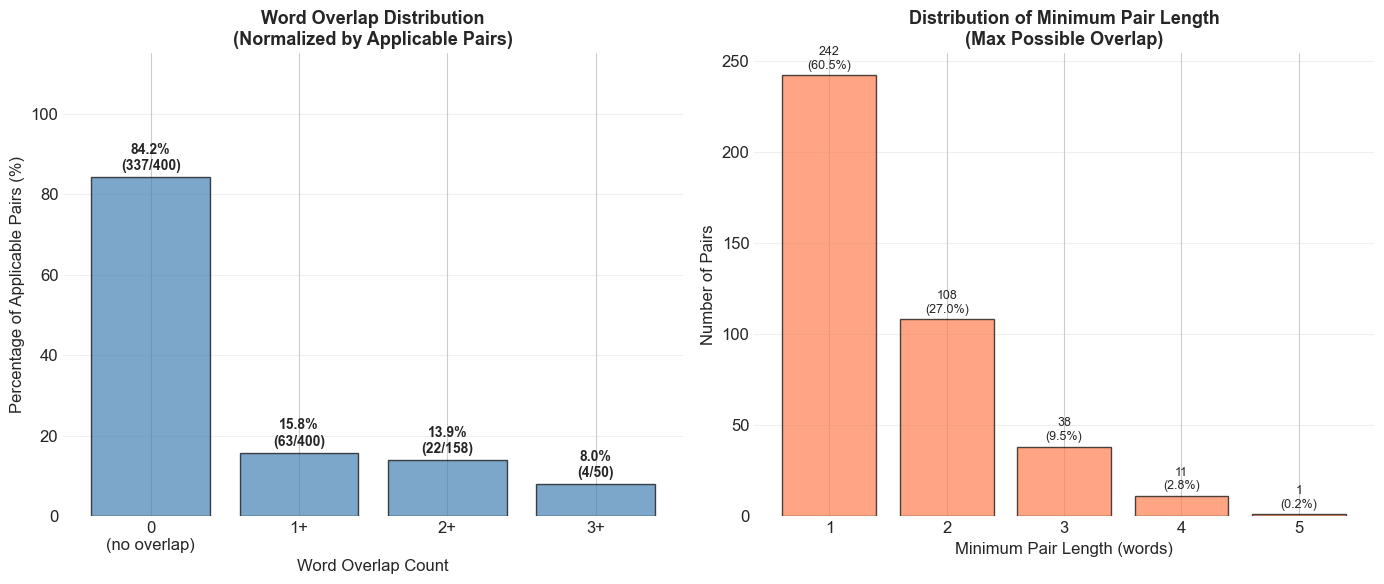


STRATIFIED WORD OVERLAP ANALYSIS

Total pairs in dataset: 400

Overlap Distribution (normalized by what's possible):
  0 overlap: 337 pairs (84.2% of all 400 pairs)
  1+ overlap: 63 pairs (15.8% of 400 pairs where this is possible)
  2+ overlap: 22 pairs (13.9% of 158 pairs where this is possible)
  3+ overlap: 4 pairs (8.0% of 50 pairs where this is possible)

📊 Key Insight: The percentages above account for name lengths.
   For example, 2+ word overlap is only possible when both names have 2+ words.


In [29]:
# Stratified Word Overlap Analysis - Addressing name length dependency
# This visualization shows overlap percentages relative to what's POSSIBLE given name lengths

import os

# Create figure with two panels
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# =============================================================================
# Panel A: Stratified bar chart - % of pairs with overlap X out of pairs where X is possible
# =============================================================================
ax1 = axes[0]

# Calculate stratified statistics
# For overlap of N words to be possible, min_pair_length must be >= N
stratified_data = []

for overlap_threshold in [1, 2, 3]:
    # Pairs where this overlap level is POSSIBLE (min_pair_length >= threshold)
    possible_pairs = df_scar[df_scar['min_pair_length'] >= overlap_threshold]
    n_possible = len(possible_pairs)
    
    # Pairs that actually HAVE this overlap level or more
    actual_pairs = possible_pairs[possible_pairs['name_overlap_count'] >= overlap_threshold]
    n_actual = len(actual_pairs)
    
    # Calculate percentage
    pct = (n_actual / n_possible * 100) if n_possible > 0 else 0
    
    stratified_data.append({
        'overlap_level': f'{overlap_threshold}+',
        'n_possible': n_possible,
        'n_actual': n_actual,
        'percentage': pct
    })

# Also add the "0 overlap" case (all pairs)
n_zero = (df_scar['name_overlap_count'] == 0).sum()
pct_zero = n_zero / len(df_scar) * 100

# Create bar chart
x_positions = [0, 1, 2, 3]
x_labels = ['0\n(no overlap)', '1+', '2+', '3+']
percentages = [pct_zero] + [d['percentage'] for d in stratified_data]
n_values = [n_zero] + [d['n_actual'] for d in stratified_data]
n_possible_values = [len(df_scar)] + [d['n_possible'] for d in stratified_data]

bars = ax1.bar(x_positions, percentages, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Word Overlap Count', fontsize=12)
ax1.set_ylabel('Percentage of Applicable Pairs (%)', fontsize=12)
ax1.set_title('Word Overlap Distribution\n(Normalized by Applicable Pairs)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(x_positions)
ax1.set_xticklabels(x_labels)
ax1.set_ylim([0, 100])

# Add value labels on top of bars with both percentage and counts
for i, (bar, pct, n_act, n_poss) in enumerate(zip(bars, percentages, n_values, n_possible_values)):
    height = bar.get_height()
    # Show percentage and fraction on bar
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{pct:.1f}%\n({n_act}/{n_poss})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_ylim([0, 115])

# =============================================================================
# Panel B: Distribution of minimum pair lengths (dataset composition)
# =============================================================================
ax2 = axes[1]

# Count minimum pair lengths
min_length_counts = df_scar['min_pair_length'].value_counts().sort_index()
bars2 = ax2.bar(min_length_counts.index, min_length_counts.values, 
               edgecolor='black', alpha=0.7, color='coral')
ax2.set_xlabel('Minimum Pair Length (words)', fontsize=12)
ax2.set_ylabel('Number of Pairs', fontsize=12)
ax2.set_title('Distribution of Minimum Pair Length\n(Max Possible Overlap)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(min_length_counts.index)

# Add value labels and percentages
for bar in bars2:
    height = bar.get_height()
    pct = height / len(df_scar) * 100
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{int(height)}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()

# Save figure
output_dir = 'results/visualizations'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'distribution_of_word_overlap_count_names.png'), 
            dpi=300, bbox_inches='tight')
print(f"✅ Saved figure to {output_dir}/distribution_of_word_overlap_count_names.png")

plt.show()

# Print detailed summary
print("\n" + "=" * 80)
print("STRATIFIED WORD OVERLAP ANALYSIS")
print("=" * 80)
print(f"\nTotal pairs in dataset: {len(df_scar)}")
print(f"\nOverlap Distribution (normalized by what's possible):")
print(f"  0 overlap: {n_zero} pairs ({pct_zero:.1f}% of all {len(df_scar)} pairs)")
for d in stratified_data:
    print(f"  {d['overlap_level']} overlap: {d['n_actual']} pairs ({d['percentage']:.1f}% of {d['n_possible']} pairs where this is possible)")

print(f"\n📊 Key Insight: The percentages above account for name lengths.")
print(f"   For example, 2+ word overlap is only possible when both names have 2+ words.")


✅ Saved figure to results/visualizations/distribution_of_jaccard_similarity_names.png


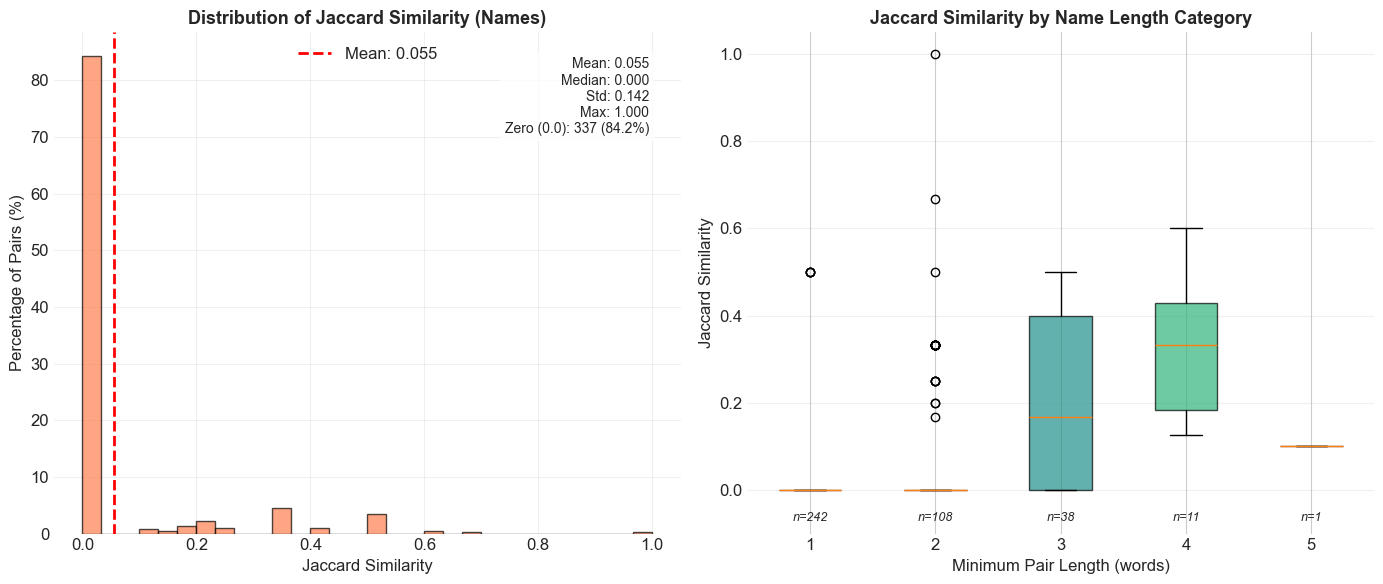


JACCARD SIMILARITY ANALYSIS

📊 Jaccard Similarity = |intersection| / |union|
   This metric naturally normalizes for name length differences.

Summary Statistics:
  Mean: 0.055
  Median: 0.000
  Std Dev: 0.142
  Range: 0.000 - 1.000

  Pairs with 0.0 similarity: 337 (84.2%)
  Pairs with >0.0 similarity: 63 (15.8%)


In [30]:
# Enhanced Distribution of Jaccard similarity - Names
# Jaccard similarity naturally normalizes for name length: |intersection| / |union|

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# =============================================================================
# Panel A: Histogram with percentage y-axis
# =============================================================================
ax1 = axes[0]

# Calculate histogram data manually to show percentages
counts, bin_edges, patches = ax1.hist(df_scar['name_jaccard'], bins=30, 
                                       edgecolor='black', alpha=0.7, color='coral',
                                       weights=np.ones(len(df_scar)) / len(df_scar) * 100)

ax1.set_xlabel('Jaccard Similarity', fontsize=12)
ax1.set_ylabel('Percentage of Pairs (%)', fontsize=12)
ax1.set_title('Distribution of Jaccard Similarity (Names)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add summary statistics as text box
stats_text = (f"Mean: {df_scar['name_jaccard'].mean():.3f}\n"
              f"Median: {df_scar['name_jaccard'].median():.3f}\n"
              f"Std: {df_scar['name_jaccard'].std():.3f}\n"
              f"Max: {df_scar['name_jaccard'].max():.3f}\n"
              f"Zero (0.0): {(df_scar['name_jaccard'] == 0).sum()} ({(df_scar['name_jaccard'] == 0).sum()/len(df_scar)*100:.1f}%)")
ax1.text(0.95, 0.95, stats_text, transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Add vertical line for mean
ax1.axvline(df_scar['name_jaccard'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {df_scar["name_jaccard"].mean():.3f}')
ax1.legend(loc='upper center')

# =============================================================================
# Panel B: Box plot with categories by minimum pair length
# =============================================================================
ax2 = axes[1]

# Group Jaccard similarity by minimum pair length
min_lengths = sorted(df_scar['min_pair_length'].unique())
data_by_length = [df_scar[df_scar['min_pair_length'] == length]['name_jaccard'].values 
                  for length in min_lengths]

bp = ax2.boxplot(data_by_length, labels=[str(l) for l in min_lengths], 
                 patch_artist=True)

# Color the boxes
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(min_lengths)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_xlabel('Minimum Pair Length (words)', fontsize=12)
ax2.set_ylabel('Jaccard Similarity', fontsize=12)
ax2.set_title('Jaccard Similarity by Name Length Category', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add sample sizes
for i, length in enumerate(min_lengths):
    n = len(df_scar[df_scar['min_pair_length'] == length])
    ax2.text(i + 1, -0.05, f'n={n}', ha='center', va='top', fontsize=9, style='italic')

ax2.set_ylim([-0.1, ax2.get_ylim()[1]])

plt.tight_layout()

# Save figure
plt.savefig(os.path.join(output_dir, 'distribution_of_jaccard_similarity_names.png'), 
            dpi=300, bbox_inches='tight')
print(f"✅ Saved figure to {output_dir}/distribution_of_jaccard_similarity_names.png")

plt.show()

# Print summary
print("\n" + "=" * 80)
print("JACCARD SIMILARITY ANALYSIS")
print("=" * 80)
print(f"\n📊 Jaccard Similarity = |intersection| / |union|")
print(f"   This metric naturally normalizes for name length differences.")
print(f"\nSummary Statistics:")
print(f"  Mean: {df_scar['name_jaccard'].mean():.3f}")
print(f"  Median: {df_scar['name_jaccard'].median():.3f}")
print(f"  Std Dev: {df_scar['name_jaccard'].std():.3f}")
print(f"  Range: {df_scar['name_jaccard'].min():.3f} - {df_scar['name_jaccard'].max():.3f}")
print(f"\n  Pairs with 0.0 similarity: {(df_scar['name_jaccard'] == 0).sum()} ({(df_scar['name_jaccard'] == 0).sum()/len(df_scar)*100:.1f}%)")
print(f"  Pairs with >0.0 similarity: {(df_scar['name_jaccard'] > 0).sum()} ({(df_scar['name_jaccard'] > 0).sum()/len(df_scar)*100:.1f}%)")


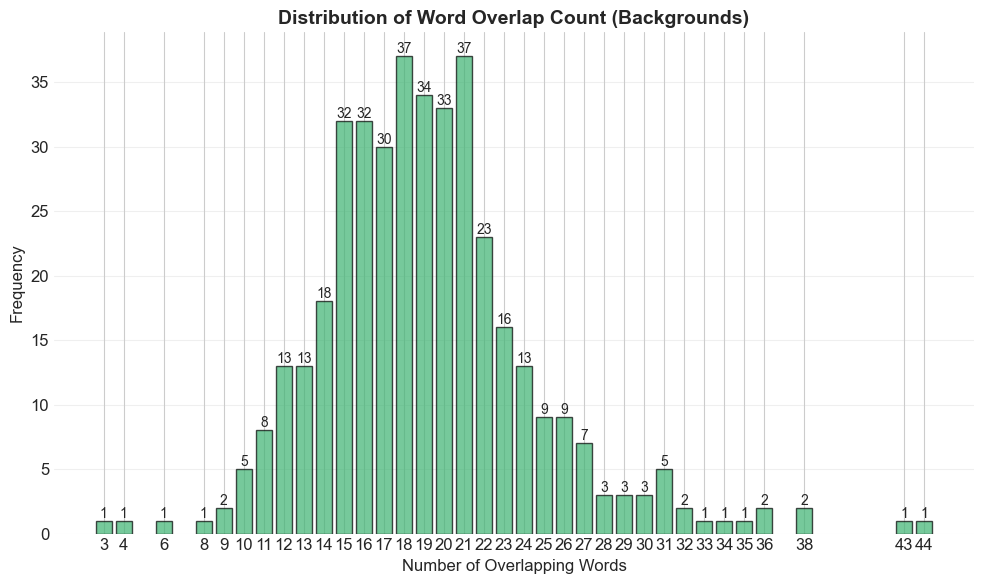

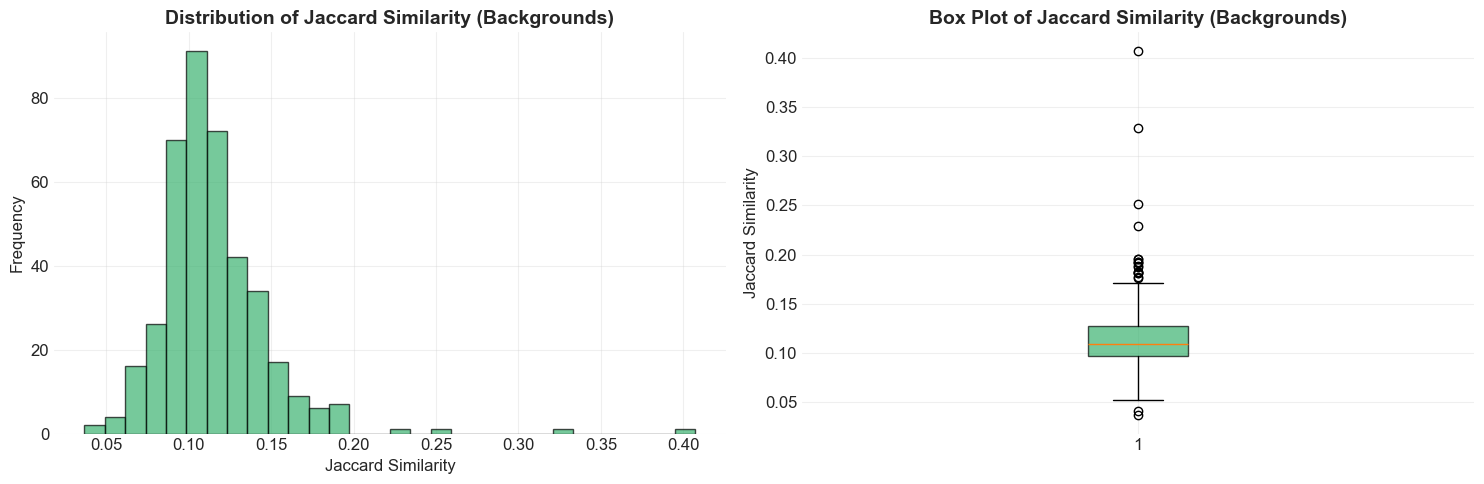

Background - Pairs with 0 overlap: 0 (0.0%)
Background - Pairs with 1+ overlap: 400 (100.0%)


In [31]:
# Background overlap visualization (if available)
if 'bg_overlap_count' in df_scar.columns:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Bar chart for discrete data
    bg_overlap_counts = df_scar['bg_overlap_count'].value_counts().sort_index()
    bars = ax.bar(bg_overlap_counts.index, bg_overlap_counts.values, 
                edgecolor='black', alpha=0.7, color='mediumseagreen')
    ax.set_xlabel('Number of Overlapping Words', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Distribution of Word Overlap Count (Backgrounds)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks(bg_overlap_counts.index)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Jaccard similarity for backgrounds
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    axes[0].hist(df_scar['bg_jaccard'], bins=30, edgecolor='black', alpha=0.7, color='mediumseagreen')
    axes[0].set_xlabel('Jaccard Similarity', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Distribution of Jaccard Similarity (Backgrounds)', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].boxplot(df_scar['bg_jaccard'], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='mediumseagreen', alpha=0.7))
    axes[1].set_ylabel('Jaccard Similarity', fontsize=12)
    axes[1].set_title('Box Plot of Jaccard Similarity (Backgrounds)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Background - Pairs with 0 overlap: {(df_scar['bg_overlap_count'] == 0).sum()} ({(df_scar['bg_overlap_count'] == 0).sum() / len(df_scar) * 100:.1f}%)")
    print(f"Background - Pairs with 1+ overlap: {(df_scar['bg_overlap_count'] > 0).sum()} ({(df_scar['bg_overlap_count'] > 0).sum() / len(df_scar) * 100:.1f}%)")
else:
    print("Background overlap data not available in the dataset.")


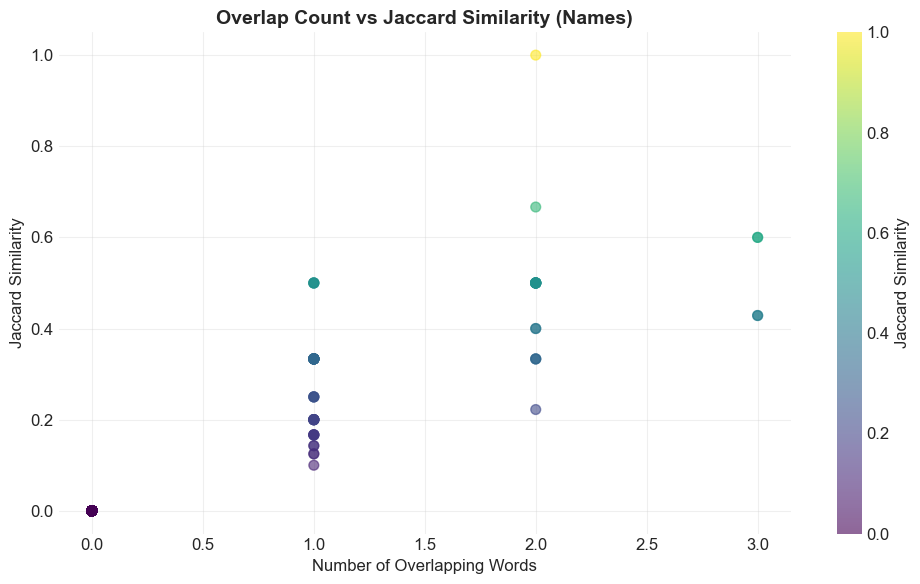

In [32]:
# Scatter plot: Overlap count vs Jaccard similarity
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df_scar['name_overlap_count'], df_scar['name_jaccard'], 
                     alpha=0.6, s=50, c=df_scar['name_jaccard'], cmap='viridis')
ax.set_xlabel('Number of Overlapping Words', fontsize=12)
ax.set_ylabel('Jaccard Similarity', fontsize=12)
ax.set_title('Overlap Count vs Jaccard Similarity (Names)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Jaccard Similarity')
plt.tight_layout()
plt.show()


## Filler vs Meaningful Word Overlap Analysis


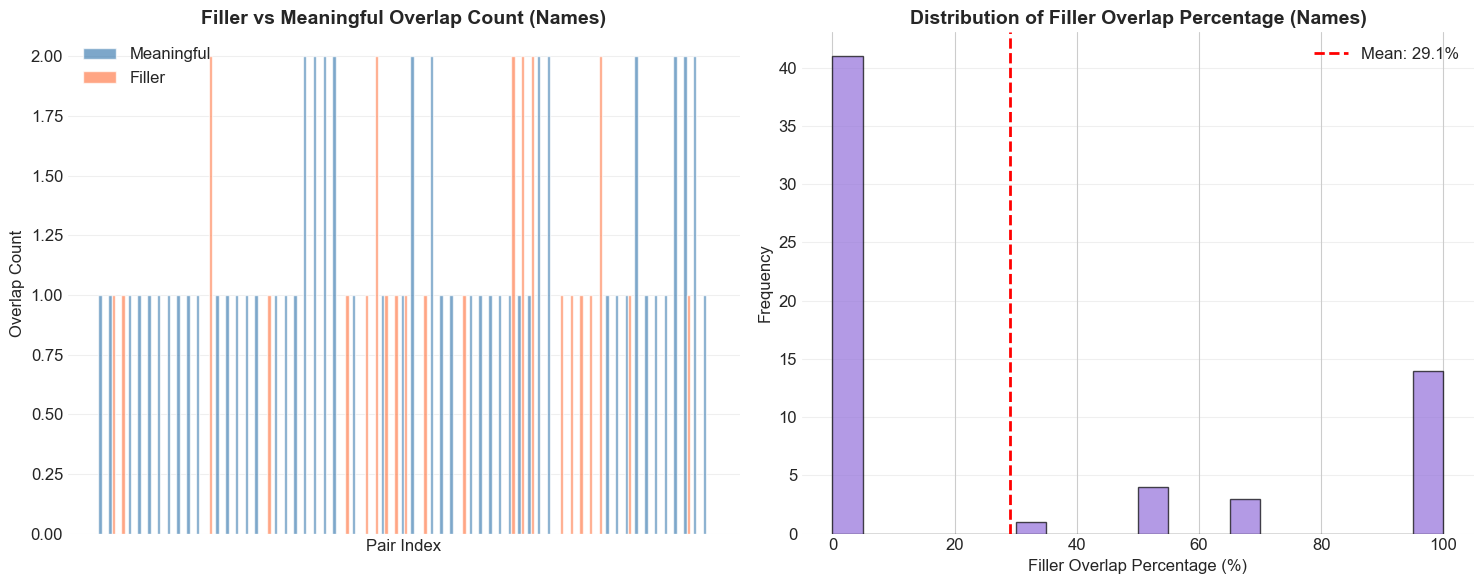


Filler vs Meaningful Overlap Statistics (for 63 pairs with overlap > 0):
Mean Filler Overlap: 0.44
Mean Meaningful Overlap: 0.97
Mean Filler Percentage: 29.1%
Mean Meaningful Percentage: 70.9%

Pairs where fillers are majority of overlap: 17 (27.0%)
Pairs where meaningful words are majority: 42 (66.7%)


In [33]:
# Comparison of filler vs meaningful overlap (for pairs with overlap > 0)
pairs_with_overlap = df_scar[df_scar['name_overlap_count'] > 0]

if len(pairs_with_overlap) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Bar chart comparing filler vs meaningful counts
    x = np.arange(len(pairs_with_overlap))
    width = 0.35
    
    axes[0].bar(x - width/2, pairs_with_overlap['name_meaningful_overlap_count'], 
                width, label='Meaningful', color='steelblue', alpha=0.7)
    axes[0].bar(x + width/2, pairs_with_overlap['name_filler_overlap_count'], 
                width, label='Filler', color='coral', alpha=0.7)
    axes[0].set_xlabel('Pair Index', fontsize=12)
    axes[0].set_ylabel('Overlap Count', fontsize=12)
    axes[0].set_title('Filler vs Meaningful Overlap Count (Names)', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].set_xticks([])  # Hide x-axis labels for clarity
    
    # Distribution of filler percentage
    axes[1].hist(pairs_with_overlap['name_filler_overlap_percentage'], bins=20, 
                 edgecolor='black', alpha=0.7, color='mediumpurple')
    axes[1].set_xlabel('Filler Overlap Percentage (%)', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title('Distribution of Filler Overlap Percentage (Names)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].axvline(pairs_with_overlap['name_filler_overlap_percentage'].mean(), 
                    color='red', linestyle='--', linewidth=2, label=f'Mean: {pairs_with_overlap["name_filler_overlap_percentage"].mean():.1f}%')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nFiller vs Meaningful Overlap Statistics (for {len(pairs_with_overlap)} pairs with overlap > 0):")
    print(f"Mean Filler Overlap: {pairs_with_overlap['name_filler_overlap_count'].mean():.2f}")
    print(f"Mean Meaningful Overlap: {pairs_with_overlap['name_meaningful_overlap_count'].mean():.2f}")
    print(f"Mean Filler Percentage: {pairs_with_overlap['name_filler_overlap_percentage'].mean():.1f}%")
    print(f"Mean Meaningful Percentage: {pairs_with_overlap['name_meaningful_overlap_percentage'].mean():.1f}%")
    print(f"\nPairs where fillers are majority of overlap: {(pairs_with_overlap['name_filler_overlap_percentage'] > 50).sum()} ({(pairs_with_overlap['name_filler_overlap_percentage'] > 50).sum() / len(pairs_with_overlap) * 100:.1f}%)")
    print(f"Pairs where meaningful words are majority: {(pairs_with_overlap['name_meaningful_overlap_percentage'] > 50).sum()} ({(pairs_with_overlap['name_meaningful_overlap_percentage'] > 50).sum() / len(pairs_with_overlap) * 100:.1f}%)")
else:
    print("No pairs with overlap > 0 to analyze.")


## Examples: High and Low Overlap Cases


In [34]:
# Find pairs with highest overlap
top_n = 63
highest_overlap = df_scar.nlargest(top_n, 'name_overlap_count')[
    ['system_a', 'system_b', 'name_overlap_count', 'name_overlapping_words', 
     'name_filler_overlap_count', 'name_filler_overlapping_words',
     'name_meaningful_overlap_count', 'name_meaningful_overlapping_words',
     'name_filler_overlap_percentage', 'name_meaningful_overlap_percentage', 'name_jaccard']
].copy()

# Convert overlapping_words sets to strings for display
highest_overlap['overlapping_words_str'] = highest_overlap['name_overlapping_words'].apply(
    lambda x: ', '.join(sorted(x)) if x else 'None'
)
highest_overlap['filler_words_str'] = highest_overlap['name_filler_overlapping_words'].apply(
    lambda x: ', '.join(sorted(x)) if x else 'None'
)
highest_overlap['meaningful_words_str'] = highest_overlap['name_meaningful_overlapping_words'].apply(
    lambda x: ', '.join(sorted(x)) if x else 'None'
)

print("=" * 80)
print(f"TOP {top_n} PAIRS WITH HIGHEST WORD OVERLAP (Names)")
print("=" * 80)
for idx, row in highest_overlap.iterrows():
    print(f"\nTarget: {row['system_a']}")
    print(f"Source: {row['system_b']}")
    print(f"Total Overlap Count: {row['name_overlap_count']}")
    print(f"  - Meaningful: {row['name_meaningful_overlap_count']} ({row['name_meaningful_overlap_percentage']:.1f}%)")
    print(f"  - Filler: {row['name_filler_overlap_count']} ({row['name_filler_overlap_percentage']:.1f}%)")
    print(f"Jaccard Similarity: {row['name_jaccard']:.3f}")
    print(f"All Overlapping Words: {row['overlapping_words_str']}")
    if row['meaningful_words_str'] != 'None':
        print(f"Meaningful Words: {row['meaningful_words_str']}")
    if row['filler_words_str'] != 'None':
        print(f"Filler Words: {row['filler_words_str']}")
    print("-" * 80)

# Display as DataFrame
display(highest_overlap[['system_a', 'system_b', 'name_overlap_count', 
                         'name_meaningful_overlap_count', 'name_filler_overlap_count',
                         'name_filler_overlap_percentage', 'name_jaccard', 
                         'overlapping_words_str']].rename(columns={
    'system_a': 'Target',
    'system_b': 'Source',
    'name_overlap_count': 'Total Overlap',
    'name_meaningful_overlap_count': 'Meaningful',
    'name_filler_overlap_count': 'Filler',
    'name_filler_overlap_percentage': 'Filler %',
    'name_jaccard': 'Jaccard',
    'overlapping_words_str': 'Overlapping Words'
}))


TOP 63 PAIRS WITH HIGHEST WORD OVERLAP (Names)

Target: The Discovery of the Cape of Good Hope
Source: The Discovery of America
Total Overlap Count: 3
  - Meaningful: 1 (33.3%)
  - Filler: 2 (66.7%)
Jaccard Similarity: 0.429
All Overlapping Words: discovery, of, the
Meaningful Words: discovery
Filler Words: of, the
--------------------------------------------------------------------------------

Target: The Discovery of the Cape of Good Hope
Source: The Discovery of India
Total Overlap Count: 3
  - Meaningful: 1 (33.3%)
  - Filler: 2 (66.7%)
Jaccard Similarity: 0.429
All Overlapping Words: discovery, of, the
Meaningful Words: discovery
Filler Words: of, the
--------------------------------------------------------------------------------

Target: The Discovery of America
Source: The Discovery of India
Total Overlap Count: 3
  - Meaningful: 1 (33.3%)
  - Filler: 2 (66.7%)
Jaccard Similarity: 0.600
All Overlapping Words: discovery, of, the
Meaningful Words: discovery
Filler Words: of, the

,Target,Source,Total Overlap,Meaningful,Filler,Filler %,Jaccard,Overlapping Words
233,The Discovery of the Cape of Good Hope,The Discovery of America,3,1,2,66.666667,0.428571,"discovery, of, the"
234,The Discovery of the Cape of Good Hope,The Discovery of India,3,1,2,66.666667,0.428571,"discovery, of, the"
235,The Discovery of America,The Discovery of India,3,1,2,66.666667,0.600000,"discovery, of, the"
379,Conservation of Charge Flow,Conservation of Water Flow,3,2,1,33.333333,0.600000,"conservation, flow, of"
3,Spread of Pathogens,Spread of Fire,2,1,1,50.000000,0.500000,"of, spread"
...,...,...,...,...,...,...,...,...
355,Light Propagation,Wave Propagation,1,1,0,0.000000,0.333333,propagation
363,planetary motion,pendulum motion,1,1,0,0.000000,0.333333,motion
364,Magnetic Resonance Imaging,Seismic Imaging,1,1,0,0.000000,0.250000,imaging
365,Energy Loss,Currency Loss,1,1,0,0.000000,0.333333,loss


In [35]:
# Find pairs with lowest overlap (but not zero, to show some interesting cases)
low_overlap = df_scar[df_scar['name_overlap_count'] > 0].nsmallest(top_n, 'name_overlap_count')[
    ['system_a', 'system_b', 'name_overlap_count', 'name_overlapping_words',
     'name_filler_overlap_count', 'name_filler_overlapping_words',
     'name_meaningful_overlap_count', 'name_meaningful_overlapping_words',
     'name_filler_overlap_percentage', 'name_meaningful_overlap_percentage', 'name_jaccard']
].copy()

if len(low_overlap) > 0:
    low_overlap['overlapping_words_str'] = low_overlap['name_overlapping_words'].apply(
        lambda x: ', '.join(sorted(x)) if x else 'None'
    )
    low_overlap['filler_words_str'] = low_overlap['name_filler_overlapping_words'].apply(
        lambda x: ', '.join(sorted(x)) if x else 'None'
    )
    low_overlap['meaningful_words_str'] = low_overlap['name_meaningful_overlapping_words'].apply(
        lambda x: ', '.join(sorted(x)) if x else 'None'
    )
    
    print("=" * 80)
    print(f"TOP {len(low_overlap)} PAIRS WITH LOWEST WORD OVERLAP (Names, but > 0)")
    print("=" * 80)
    for idx, row in low_overlap.iterrows():
        print(f"\nTarget: {row['system_a']}")
        print(f"Source: {row['system_b']}")
        print(f"Total Overlap Count: {row['name_overlap_count']}")
        print(f"  - Meaningful: {row['name_meaningful_overlap_count']} ({row['name_meaningful_overlap_percentage']:.1f}%)")
        print(f"  - Filler: {row['name_filler_overlap_count']} ({row['name_filler_overlap_percentage']:.1f}%)")
        print(f"Jaccard Similarity: {row['name_jaccard']:.3f}")
        print(f"All Overlapping Words: {row['overlapping_words_str']}")
        if row['meaningful_words_str'] != 'None':
            print(f"Meaningful Words: {row['meaningful_words_str']}")
        if row['filler_words_str'] != 'None':
            print(f"Filler Words: {row['filler_words_str']}")
        print("-" * 80)
    
    display(low_overlap[['system_a', 'system_b', 'name_overlap_count',
                         'name_meaningful_overlap_count', 'name_filler_overlap_count',
                         'name_filler_overlap_percentage', 'name_jaccard', 
                         'overlapping_words_str']].rename(columns={
        'system_a': 'Target',
        'system_b': 'Source',
        'name_overlap_count': 'Total Overlap',
        'name_meaningful_overlap_count': 'Meaningful',
        'name_filler_overlap_count': 'Filler',
        'name_filler_overlap_percentage': 'Filler %',
        'name_jaccard': 'Jaccard',
        'overlapping_words_str': 'Overlapping Words'
    }))
else:
    print("No pairs with overlap > 0 found.")


TOP 63 PAIRS WITH LOWEST WORD OVERLAP (Names, but > 0)

Target: biological clock
Source: clock
Total Overlap Count: 1
  - Meaningful: 1 (100.0%)
  - Filler: 0 (0.0%)
Jaccard Similarity: 0.500
All Overlapping Words: clock
Meaningful Words: clock
--------------------------------------------------------------------------------

Target: Bill of Rights
Source: Declaration of Independence
Total Overlap Count: 1
  - Meaningful: 0 (0.0%)
  - Filler: 1 (100.0%)
Jaccard Similarity: 0.200
All Overlapping Words: of
Filler Words: of
--------------------------------------------------------------------------------

Target: Declaration of Independence
Source: Constitution of 1787
Total Overlap Count: 1
  - Meaningful: 0 (0.0%)
  - Filler: 1 (100.0%)
Jaccard Similarity: 0.200
All Overlapping Words: of
Filler Words: of
--------------------------------------------------------------------------------

Target: Reformation in Russia in 1861
Source: Meiji Restoration in Japan
Total Overlap Count: 1
  - Meani

,Target,Source,Total Overlap,Meaningful,Filler,Filler %,Jaccard,Overlapping Words
0,biological clock,clock,1,1,0,0.000000,0.500000,clock
199,Bill of Rights,Declaration of Independence,1,0,1,100.000000,0.200000,of
202,Declaration of Independence,Constitution of 1787,1,0,1,100.000000,0.200000,of
206,Reformation in Russia in 1861,Meiji Restoration in Japan,1,0,1,100.000000,0.142857,in
209,Westernization Movement,Reform Movement of 1898,1,1,0,0.000000,0.200000,movement
...,...,...,...,...,...,...,...,...
239,American Presidential System,French Presidential System,2,2,0,0.000000,0.500000,"presidential, system"
235,The Discovery of America,The Discovery of India,3,1,2,66.666667,0.600000,"discovery, of, the"
234,The Discovery of the Cape of Good Hope,The Discovery of India,3,1,2,66.666667,0.428571,"discovery, of, the"
379,Conservation of Charge Flow,Conservation of Water Flow,3,2,1,33.333333,0.600000,"conservation, flow, of"


In [36]:
# Pairs with zero overlap
zero_overlap_count = (df_scar['name_overlap_count'] == 0).sum()
if zero_overlap_count > 0:
    print(f"Pairs with ZERO word overlap: {zero_overlap_count} ({zero_overlap_count/len(df_scar)*100:.1f}%)")
    print("\nSample of pairs with zero overlap:")
    zero_overlap_sample = df_scar[df_scar['name_overlap_count'] == 0].head(10)[
        ['system_a', 'system_b', 'name_overlap_count']
    ]
    display(zero_overlap_sample.rename(columns={
        'system_a': 'Target',
        'system_b': 'Source',
        'name_overlap_count': 'Overlap Count'
    }))


Pairs with ZERO word overlap: 337 (84.2%)

Sample of pairs with zero overlap:


,Target,Source,Overlap Count
1,Biosphere,Library,0
2,Respiratory system,engine,0
4,Gene editing,kirigami,0
5,Water Cycle,Circular Economy,0
6,Cell division,the factory's production line,0
7,Origin of Life,Chemical Reactions,0
9,Ecosystem,Machines,0
10,Nervous System,Circuits,0
11,Immune System,Army,0
12,Cell Membranes,Walls,0


## Summary Statistics Table


In [37]:
# Create summary statistics table
summary_stats = {
    'Metric': [
        'Total Pairs',
        'Mean Total Overlap Count',
        'Mean Meaningful Overlap Count',
        'Mean Filler Overlap Count',
        'Mean Filler Overlap %',
        'Mean Meaningful Overlap %',
        'Pairs with 0 Overlap',
        'Pairs with 1+ Overlap',
        'Pairs where Fillers > 50%',
        'Pairs where Meaningful > 50%',
        'Mean Jaccard Similarity',
        'Median Jaccard Similarity',
        'Max Jaccard Similarity'
    ],
    'Value (Names)': [
        len(df_scar),
        f"{df_scar['name_overlap_count'].mean():.2f}",
        f"{df_scar['name_meaningful_overlap_count'].mean():.2f}",
        f"{df_scar['name_filler_overlap_count'].mean():.2f}",
        f"{df_scar['name_filler_overlap_percentage'].mean():.1f}%",
        f"{df_scar['name_meaningful_overlap_percentage'].mean():.1f}%",
        f"{(df_scar['name_overlap_count'] == 0).sum()} ({(df_scar['name_overlap_count'] == 0).sum()/len(df_scar)*100:.1f}%)",
        f"{(df_scar['name_overlap_count'] > 0).sum()} ({(df_scar['name_overlap_count'] > 0).sum()/len(df_scar)*100:.1f}%)",
        f"{(df_scar[df_scar['name_overlap_count'] > 0]['name_filler_overlap_percentage'] > 50).sum() if (df_scar['name_overlap_count'] > 0).sum() > 0 else 0}",
        f"{(df_scar[df_scar['name_overlap_count'] > 0]['name_meaningful_overlap_percentage'] > 50).sum() if (df_scar['name_overlap_count'] > 0).sum() > 0 else 0}",
        f"{df_scar['name_jaccard'].mean():.3f}",
        f"{df_scar['name_jaccard'].median():.3f}",
        f"{df_scar['name_jaccard'].max():.3f}"
    ]
}

if 'bg_overlap_count' in df_scar.columns:
    summary_stats['Value (Backgrounds)'] = [
        len(df_scar),
        f"{df_scar['bg_overlap_count'].mean():.2f}",
        f"{df_scar['bg_meaningful_overlap_count'].mean():.2f}",
        f"{df_scar['bg_filler_overlap_count'].mean():.2f}",
        f"{df_scar['bg_filler_overlap_percentage'].mean():.1f}%",
        f"{df_scar['bg_meaningful_overlap_percentage'].mean():.1f}%",
        f"{(df_scar['bg_overlap_count'] == 0).sum()} ({(df_scar['bg_overlap_count'] == 0).sum()/len(df_scar)*100:.1f}%)",
        f"{(df_scar['bg_overlap_count'] > 0).sum()} ({(df_scar['bg_overlap_count'] > 0).sum()/len(df_scar)*100:.1f}%)",
        f"{(df_scar[df_scar['bg_overlap_count'] > 0]['bg_filler_overlap_percentage'] > 50).sum() if (df_scar['bg_overlap_count'] > 0).sum() > 0 else 0}",
        f"{(df_scar[df_scar['bg_overlap_count'] > 0]['bg_meaningful_overlap_percentage'] > 50).sum() if (df_scar['bg_overlap_count'] > 0).sum() > 0 else 0}",
        f"{df_scar['bg_jaccard'].mean():.3f}",
        f"{df_scar['bg_jaccard'].median():.3f}",
        f"{df_scar['bg_jaccard'].max():.3f}"
    ]

summary_df = pd.DataFrame(summary_stats)
display(summary_df)


,Metric,Value (Names),Value (Backgrounds)
0,Total Pairs,400,400
1,Mean Total Overlap Count,0.22,19.14
2,Mean Meaningful Overlap Count,0.15,5.29
3,Mean Filler Overlap Count,0.07,13.85
4,Mean Filler Overlap %,4.6%,74.8%
5,Mean Meaningful Overlap %,11.2%,25.2%
6,Pairs with 0 Overlap,337 (84.2%),0 (0.0%)
7,Pairs with 1+ Overlap,63 (15.8%),400 (100.0%)
8,Pairs where Fillers > 50%,17,384
9,Pairs where Meaningful > 50%,42,13


## Most Common Overlapping Words


Top 20 Most Common Overlapping Words Across All Pairs:
of                  :   14 pairs (3.5%)
system              :   12 pairs (3.0%)
the                 :   10 pairs (2.5%)
movement            :    3 pairs (0.8%)
ancient             :    3 pairs (0.8%)
discovery           :    3 pairs (0.8%)
political           :    2 pairs (0.5%)
revolution          :    2 pairs (0.5%)
propagation         :    2 pairs (0.5%)
clock               :    1 pairs (0.2%)
spread              :    1 pairs (0.2%)
evolution           :    1 pairs (0.2%)
chain               :    1 pairs (0.2%)
helix               :    1 pairs (0.2%)
selection           :    1 pairs (0.2%)
desert              :    1 pairs (0.2%)
storm               :    1 pairs (0.2%)
immunity            :    1 pairs (0.2%)
networks            :    1 pairs (0.2%)
forest              :    1 pairs (0.2%)


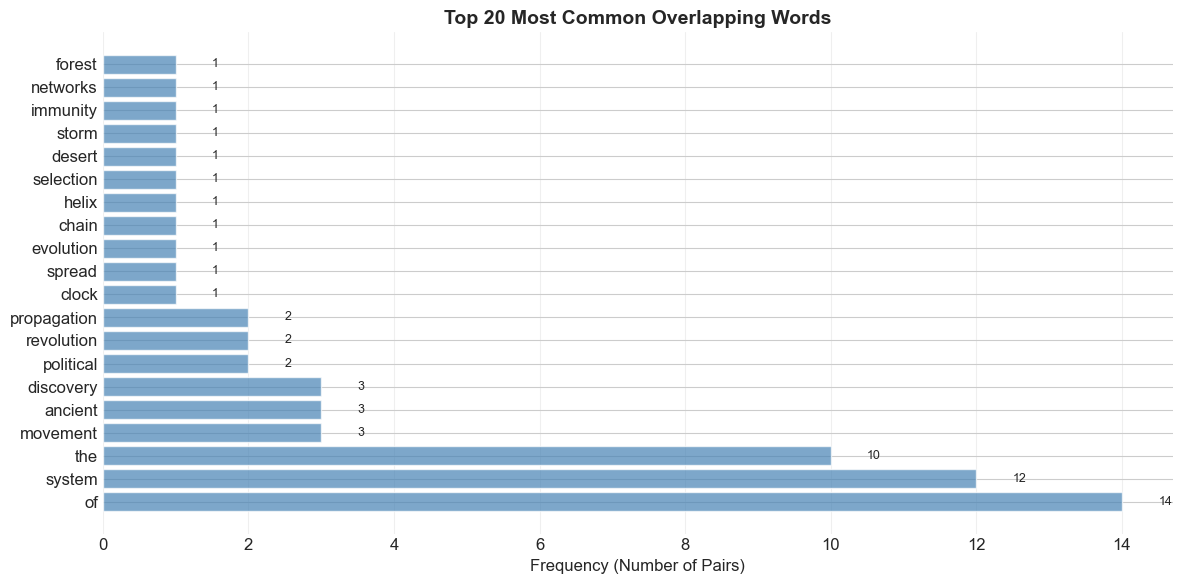

In [38]:
# Collect all overlapping words across all pairs
all_overlapping_words = []
for words_set in df_scar['name_overlapping_words']:
    if words_set:
        all_overlapping_words.extend(list(words_set))

# Count frequency of each overlapping word
word_counts = Counter(all_overlapping_words)

# Display most common overlapping words
top_words = 20
most_common_words = word_counts.most_common(top_words)

print(f"Top {top_words} Most Common Overlapping Words Across All Pairs:")
print("=" * 60)
for word, count in most_common_words:
    print(f"{word:20s}: {count:4d} pairs ({count/len(df_scar)*100:.1f}%)")

# Visualize as bar chart
if most_common_words:
    words, counts = zip(*most_common_words)
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(range(len(words)), counts, color='steelblue', alpha=0.7)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words)
    ax.set_xlabel('Frequency (Number of Pairs)', fontsize=12)
    ax.set_title(f'Top {top_words} Most Common Overlapping Words', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add value labels on bars
    for i, (bar, count) in enumerate(zip(bars, counts)):
        ax.text(count + 0.5, i, str(count), va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()


In [39]:
df_scar.columns

Index(['id', 'system_a', 'system_b', 'system_a_domain', 'system_b_domain',
       'system_a_background', 'system_b_background', 'mappings_parsed',
       'mapping_count', 'explanation_parsed', 'explanation_count',
       'system_a_bg_wc', 'system_b_bg_wc', 'name_overlap_count',
       'name_overlapping_words', 'name_filler_overlap_count',
       'name_filler_overlapping_words', 'name_meaningful_overlap_count',
       'name_meaningful_overlapping_words', 'name_filler_overlap_percentage',
       'name_meaningful_overlap_percentage', 'name_jaccard',
       'bg_overlap_count', 'bg_overlapping_words', 'bg_filler_overlap_count',
       'bg_filler_overlapping_words', 'bg_meaningful_overlap_count',
       'bg_meaningful_overlapping_words', 'bg_filler_overlap_percentage',
       'bg_meaningful_overlap_percentage', 'bg_jaccard', 'target_word_count',
       'source_word_count', 'min_pair_length'],
      dtype='object')

In [40]:
# Create a display-friendly DataFrame with overlapping words
display_df = df_scar[['system_a', 'system_b', 'name_overlap_count', 'name_jaccard', 'name_overlapping_words', 'name_filler_overlapping_words', 'name_meaningful_overlapping_words' ]].copy()
display_df['overlapping_words_str'] = display_df['name_overlapping_words'].apply(
    lambda x: ', '.join(sorted(x)) if x else 'None'
)

# Rename columns for better display
display_df = display_df.rename(columns={
    'system_a': 'Target',
    'system_b': 'Source',
    'name_overlap_count': 'Overlap Count',
    'name_jaccard': 'Jaccard Similarity',
    'overlapping_words_str': 'Overlapping Words'
})

# Sort by overlap count (descending)
display_df = display_df.sort_values('Overlap Count', ascending=False)

print("All Source-Target Pairs with Word Overlap Information")
print("=" * 100)
print(f"Total pairs: {len(display_df)}")
print("\nFirst 20 pairs (sorted by overlap count):")
display(display_df.head(20))

# Option to display all (commented out to avoid overwhelming output)
# Uncomment the line below if you want to see all pairs
# display(display_df)


All Source-Target Pairs with Word Overlap Information
Total pairs: 400

First 20 pairs (sorted by overlap count):


,Target,Source,Overlap Count,Jaccard Similarity,name_overlapping_words,name_filler_overlapping_words,name_meaningful_overlapping_words,Overlapping Words
379,Conservation of Charge Flow,Conservation of Water Flow,3,0.600000,"{of, conservation, flow}",{of},"{conservation, flow}","conservation, flow, of"
233,The Discovery of the Cape of Good Hope,The Discovery of America,3,0.428571,"{the, of, discovery}","{the, of}",{discovery},"discovery, of, the"
234,The Discovery of the Cape of Good Hope,The Discovery of India,3,0.428571,"{the, of, discovery}","{the, of}",{discovery},"discovery, of, the"
235,The Discovery of America,The Discovery of India,3,0.600000,"{the, of, discovery}","{the, of}",{discovery},"discovery, of, the"
200,The Bill of Rights,The Constitution of 1787,2,0.333333,"{the, of}","{the, of}",{},"of, the"
203,Declaration of Independence,Declaration of Human Rights,2,0.400000,"{of, declaration}",{of},{declaration},"declaration, of"
207,Industrial Revolution,The Second Industrial Revolution,2,0.500000,"{industrial, revolution}",{},"{industrial, revolution}","industrial, revolution"
201,Bill of Rights,Declaration of Human Rights,2,0.400000,"{rights, of}",{of},{rights},"of, rights"
56,The Evolution of Viruses,The Production Line of a Car Factory,2,0.222222,"{the, of}","{the, of}",{},"of, the"
192,Japanese Government System,British Government System,2,0.500000,"{system, government}",{},"{system, government}","government, system"


In [41]:
#how many records have 1.0 jaccard similarity?
df_scar[df_scar['name_jaccard'] == 1.0]

,id,system_a,system_b,system_a_domain,system_b_domain,system_a_background,system_b_background,mappings_parsed,mapping_count,explanation_parsed,...,bg_filler_overlap_count,bg_filler_overlapping_words,bg_meaningful_overlap_count,bg_meaningful_overlapping_words,bg_filler_overlap_percentage,bg_meaningful_overlap_percentage,bg_jaccard,target_word_count,source_word_count,min_pair_length
372,373,Sound system,sound system,Physics,Physics,A sound system is a device used to reproduce a...,A sound system is an advanced technological im...,"[['sound', 'music'], ['throat', 'speaker'], ['...",4,['Sound corresponds to music: sound in the voc...,...,16,"{with, from, a, by, of, s, is, or, to, at, it,...",10,"{music, system, enjoy, tool, whether, sound, p...",61.538462,38.461538,0.18705,2,2,2


## Word Overlap vs RAG Top-K Analysis

Analyze how often sources with word overlap appear in the top-k results from RAG embedding methods.


In [42]:
# Load RAG results for different embedding modes
import ast
import os

RAG_RESULTS_DIR = 'results'
embedding_modes = ['name_only', 'name_background', 'name_properties', 'name_properties_background']

rag_results_dict = {}

for mode in embedding_modes:
    rag_file = os.path.join(RAG_RESULTS_DIR, f'rag_results_{mode}.csv')
    if os.path.exists(rag_file):
        df_rag = pd.read_csv(rag_file)
        # Parse the top_k_sources column (it's stored as a string representation of a list)
        df_rag['top_k_sources_parsed'] = df_rag['top_k_sources'].apply(
            lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) else []
        )
        rag_results_dict[mode] = df_rag
        print(f"✅ Loaded {len(df_rag)} RAG results for mode: {mode}")
    else:
        print(f"⚠️ RAG results file not found: {rag_file}")

print(f"\nLoaded RAG results for {len(rag_results_dict)} embedding modes")


✅ Loaded 400 RAG results for mode: name_only
✅ Loaded 400 RAG results for mode: name_background
✅ Loaded 400 RAG results for mode: name_properties
✅ Loaded 400 RAG results for mode: name_properties_background

Loaded RAG results for 4 embedding modes


In [43]:
# Prepare word overlap data: identify pairs with overlap
# df_scar already has word overlap calculations from earlier cells
pairs_with_overlap = df_scar[df_scar['name_overlap_count'] > 0].copy()

print(f"Total pairs in dataset: {len(df_scar)}")
print(f"Pairs with word overlap: {len(pairs_with_overlap)} ({len(pairs_with_overlap)/len(df_scar)*100:.1f}%)")
print(f"\nOverlap count distribution:")
print(pairs_with_overlap['name_overlap_count'].value_counts().sort_index())


Total pairs in dataset: 400
Pairs with word overlap: 63 (15.8%)

Overlap count distribution:
name_overlap_count
1    41
2    18
3     4
Name: count, dtype: int64


In [44]:
# Function to normalize text for matching (case-insensitive)
def normalize_for_matching(text):
    """Normalize text for case-insensitive matching"""
    if pd.isna(text):
        return ""
    return str(text).lower().strip()

# Function to check if source appears in RAG top-k results
def check_source_in_rag_topk(target_name, source_name, rag_df, top_k=20):
    """
    Check if a source appears in RAG top-k results for a given target
    
    Args:
        target_name: Target system name
        source_name: Source system name to check
        rag_df: RAG results DataFrame
        top_k: Top-k to check (default 20)
        
    Returns:
        dict with:
        - found: bool, whether source was found
        - rank: int, rank if found (1-based), -1 if not found
        - in_top_k: bool, whether in top-k
    """
    # Find rows for this target
    target_rows = rag_df[rag_df['target'].apply(normalize_for_matching) == normalize_for_matching(target_name)]
    
    if len(target_rows) == 0:
        return {'found': False, 'rank': -1, 'in_top_k': False}
    
    # Check the first row (should be unique per target)
    row = target_rows.iloc[0]
    top_k_sources = row['top_k_sources_parsed']
    
    # Normalize source name for matching
    normalized_source = normalize_for_matching(source_name)
    
    # Check if source appears in top-k
    for i, rag_source in enumerate(top_k_sources[:top_k]):
        normalized_rag_source = normalize_for_matching(rag_source)
        # Check for exact match or substring match
        if (normalized_source == normalized_rag_source or 
            normalized_source in normalized_rag_source or 
            normalized_rag_source in normalized_source):
            return {'found': True, 'rank': i + 1, 'in_top_k': True}
    
    return {'found': False, 'rank': -1, 'in_top_k': False}


In [45]:
# Match word overlap pairs with RAG results for each embedding mode
analysis_results = {}

for mode, rag_df in rag_results_dict.items():
    print(f"\nAnalyzing mode: {mode}")
    print("-" * 60)
    
    results = []
    # Include ALL pairs (both with and without overlap) for comparison
    for idx, row in df_scar.iterrows():
        target = row['system_a']
        source = row['system_b']
        
        # Check if source appears in RAG top-k
        match_info = check_source_in_rag_topk(target, source, rag_df, top_k=20)
        
        results.append({
            'target': target,
            'source': source,
            'overlap_count': row['name_overlap_count'],
            'meaningful_overlap_count': row['name_meaningful_overlap_count'],
            'filler_overlap_count': row['name_filler_overlap_count'],
            'filler_overlap_percentage': row['name_filler_overlap_percentage'],
            'meaningful_overlap_percentage': row['name_meaningful_overlap_percentage'],
            'found_in_rag': match_info['found'],
            'rag_rank': match_info['rank'],
            'in_top_k': match_info['in_top_k']
        })
    
    analysis_df = pd.DataFrame(results)
    analysis_results[mode] = analysis_df
    
    # Print summary
    total = len(analysis_df)
    found = analysis_df['found_in_rag'].sum()
    percentage = (found / total * 100) if total > 0 else 0
    
    # Separate stats for pairs with and without overlap
    with_overlap = analysis_df[analysis_df['overlap_count'] > 0]
    zero_overlap = analysis_df[analysis_df['overlap_count'] == 0]
    
    print(f"Total pairs: {total}")
    print(f"  - With overlap: {len(with_overlap)}")
    print(f"  - Zero overlap: {len(zero_overlap)}")
    print(f"\nFound in RAG top-20: {found} ({percentage:.1f}%)")
    print(f"  - With overlap: {with_overlap['found_in_rag'].sum()} ({(with_overlap['found_in_rag'].sum() / len(with_overlap) * 100) if len(with_overlap) > 0 else 0:.1f}%)")
    print(f"  - Zero overlap: {zero_overlap['found_in_rag'].sum()} ({(zero_overlap['found_in_rag'].sum() / len(zero_overlap) * 100) if len(zero_overlap) > 0 else 0:.1f}%)")
    print(f"Not found: {total - found} ({(total - found) / total * 100:.1f}%)")
    
    if found > 0:
        avg_rank = analysis_df[analysis_df['found_in_rag']]['rag_rank'].mean()
        print(f"Average rank when found: {avg_rank:.2f}")



Analyzing mode: name_only
------------------------------------------------------------


Total pairs: 400
  - With overlap: 63
  - Zero overlap: 337

Found in RAG top-20: 241 (60.2%)
  - With overlap: 60 (95.2%)
  - Zero overlap: 181 (53.7%)
Not found: 159 (39.8%)
Average rank when found: 5.81

Analyzing mode: name_background
------------------------------------------------------------
Total pairs: 400
  - With overlap: 63
  - Zero overlap: 337

Found in RAG top-20: 217 (54.2%)
  - With overlap: 57 (90.5%)
  - Zero overlap: 160 (47.5%)
Not found: 183 (45.8%)
Average rank when found: 6.66

Analyzing mode: name_properties
------------------------------------------------------------
Total pairs: 400
  - With overlap: 63
  - Zero overlap: 337

Found in RAG top-20: 277 (69.2%)
  - With overlap: 60 (95.2%)
  - Zero overlap: 217 (64.4%)
Not found: 123 (30.8%)
Average rank when found: 5.41

Analyzing mode: name_properties_background
------------------------------------------------------------
Total pairs: 400
  - With overlap: 63
  - Zero overlap: 337

Found in RAG top-20: 239 (59

### Calculate detailed statistics by overlap category for each embedding mode

In [46]:

detailed_stats = {}

for mode, analysis_df in analysis_results.items():
    stats = {
        'mode': mode,
        'total_pairs': len(analysis_df),
        'found_in_top_k': analysis_df['found_in_rag'].sum(),
        'found_percentage': (analysis_df['found_in_rag'].sum() / len(analysis_df) * 100) if len(analysis_df) > 0 else 0,
        'avg_rank_when_found': analysis_df[analysis_df['found_in_rag']]['rag_rank'].mean() if analysis_df['found_in_rag'].sum() > 0 else None,
    }
    
    # Statistics by overlap count
    overlap_stats = []
    for overlap_count in sorted(analysis_df['overlap_count'].unique()):
        subset = analysis_df[analysis_df['overlap_count'] == overlap_count]
        found = subset['found_in_rag'].sum()
        stats_by_count = {
            'overlap_count': overlap_count,
            'total': len(subset),
            'found': found,
            'found_percentage': (found / len(subset) * 100) if len(subset) > 0 else 0,
            'avg_rank': subset[subset['found_in_rag']]['rag_rank'].mean() if found > 0 else None
        }
        overlap_stats.append(stats_by_count)
    stats['by_overlap_count'] = pd.DataFrame(overlap_stats)
    
    # Statistics by meaningful vs filler
    meaningful_only = analysis_df[analysis_df['meaningful_overlap_count'] > 0]
    filler_only = analysis_df[(analysis_df['meaningful_overlap_count'] == 0) & (analysis_df['filler_overlap_count'] > 0)]
    both = analysis_df[(analysis_df['meaningful_overlap_count'] > 0) & (analysis_df['filler_overlap_count'] > 0)]
    zero_overlap = analysis_df[analysis_df['overlap_count'] == 0]
    
    stats['meaningful_only'] = {
        'total': len(meaningful_only),
        'found': meaningful_only['found_in_rag'].sum(),
        'found_percentage': (meaningful_only['found_in_rag'].sum() / len(meaningful_only) * 100) if len(meaningful_only) > 0 else 0,
        'avg_rank': meaningful_only[meaningful_only['found_in_rag']]['rag_rank'].mean() if meaningful_only['found_in_rag'].sum() > 0 else None
    }
    
    stats['filler_only'] = {
        'total': len(filler_only),
        'found': filler_only['found_in_rag'].sum(),
        'found_percentage': (filler_only['found_in_rag'].sum() / len(filler_only) * 100) if len(filler_only) > 0 else 0,
        'avg_rank': filler_only[filler_only['found_in_rag']]['rag_rank'].mean() if filler_only['found_in_rag'].sum() > 0 else None
    }
    
    stats['both'] = {
        'total': len(both),
        'found': both['found_in_rag'].sum(),
        'found_percentage': (both['found_in_rag'].sum() / len(both) * 100) if len(both) > 0 else 0,
        'avg_rank': both[both['found_in_rag']]['rag_rank'].mean() if both['found_in_rag'].sum() > 0 else None
    }
    
    stats['zero_overlap'] = {
        'total': len(zero_overlap),
        'found': zero_overlap['found_in_rag'].sum(),
        'found_percentage': (zero_overlap['found_in_rag'].sum() / len(zero_overlap) * 100) if len(zero_overlap) > 0 else 0,
        'avg_rank': zero_overlap[zero_overlap['found_in_rag']]['rag_rank'].mean() if zero_overlap['found_in_rag'].sum() > 0 else None
    }
    
    detailed_stats[mode] = stats

# Display summary statistics
print("=" * 80)
print("SUMMARY STATISTICS: Word Overlap Pairs in RAG Top-K")
print("=" * 80)

summary_data = []
for mode, stats in detailed_stats.items():
    summary_data.append({
        'Embedding Mode': mode,
        'Total Pairs': stats['total_pairs'],
        'Found in Top-K': stats['found_in_top_k'],
        'Found %': f"{stats['found_percentage']:.1f}%",
        'Avg Rank (when found)': f"{stats['avg_rank_when_found']:.2f}" if stats['avg_rank_when_found'] else "N/A"
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)


SUMMARY STATISTICS: Word Overlap Pairs in RAG Top-K


,Embedding Mode,Total Pairs,Found in Top-K,Found %,Avg Rank (when found)
0,name_only,400,241,60.2%,5.81
1,name_background,400,217,54.2%,6.66
2,name_properties,400,277,69.2%,5.41
3,name_properties_background,400,239,59.8%,6.33


In [47]:
# Display statistics by overlap count for each mode
for mode, stats in detailed_stats.items():
    print(f"\n{'='*80}")
    print(f"Mode: {mode}")
    print(f"{'='*80}")
    print("\nBy Overlap Count:")
    display(stats['by_overlap_count'])
    
    print("\nBy Overlap Type:")
    type_stats = pd.DataFrame([
        {
            'Type': 'Zero Overlap',
            'Total': stats['zero_overlap']['total'],
            'Found': stats['zero_overlap']['found'],
            'Found %': f"{stats['zero_overlap']['found_percentage']:.1f}%",
            'Avg Rank': f"{stats['zero_overlap']['avg_rank']:.2f}" if stats['zero_overlap']['avg_rank'] else "N/A"
        },
        {
            'Type': 'Meaningful Only',
            'Total': stats['meaningful_only']['total'],
            'Found': stats['meaningful_only']['found'],
            'Found %': f"{stats['meaningful_only']['found_percentage']:.1f}%",
            'Avg Rank': f"{stats['meaningful_only']['avg_rank']:.2f}" if stats['meaningful_only']['avg_rank'] else "N/A"
        },
        {
            'Type': 'Filler Only',
            'Total': stats['filler_only']['total'],
            'Found': stats['filler_only']['found'],
            'Found %': f"{stats['filler_only']['found_percentage']:.1f}%",
            'Avg Rank': f"{stats['filler_only']['avg_rank']:.2f}" if stats['filler_only']['avg_rank'] else "N/A"
        },
        {
            'Type': 'Both Meaningful & Filler',
            'Total': stats['both']['total'],
            'Found': stats['both']['found'],
            'Found %': f"{stats['both']['found_percentage']:.1f}%",
            'Avg Rank': f"{stats['both']['avg_rank']:.2f}" if stats['both']['avg_rank'] else "N/A"
        }
    ])
    display(type_stats)



Mode: name_only

By Overlap Count:


,overlap_count,total,found,found_percentage,avg_rank
0,0,337,181,53.709199,6.917127
1,1,41,39,95.121951,2.435897
2,2,18,17,94.444444,2.764706
3,3,4,4,100.000000,1.500000



By Overlap Type:


,Type,Total,Found,Found %,Avg Rank
0,Zero Overlap,337,181,53.7%,6.92
1,Meaningful Only,49,48,98.0%,1.73
2,Filler Only,14,12,85.7%,5.42
3,Both Meaningful & Filler,8,8,100.0%,2.25



Mode: name_background

By Overlap Count:


...

,Type,Total,Found,Found %,Avg Rank
0,Zero Overlap,337,217,64.4%,6.15
1,Meaningful Only,49,49,100.0%,2.67
2,Filler Only,14,11,78.6%,3.09
3,Both Meaningful & Filler,8,8,100.0%,2.25



Mode: name_properties_background

By Overlap Count:


,overlap_count,total,found,found_percentage,avg_rank
0,0,337,180,53.412463,7.377778
1,1,41,39,95.121951,3.564103
2,2,18,16,88.888889,2.562500
3,3,4,4,100.000000,1.500000



By Overlap Type:


,Type,Total,Found,Found %,Avg Rank
0,Zero Overlap,337,180,53.4%,7.38
1,Meaningful Only,49,48,98.0%,2.88
2,Filler Only,14,11,78.6%,4.36
3,Both Meaningful & Filler,8,8,100.0%,3.38


✅ Saved figure to results/visualizations/word_overlap_distribution.png


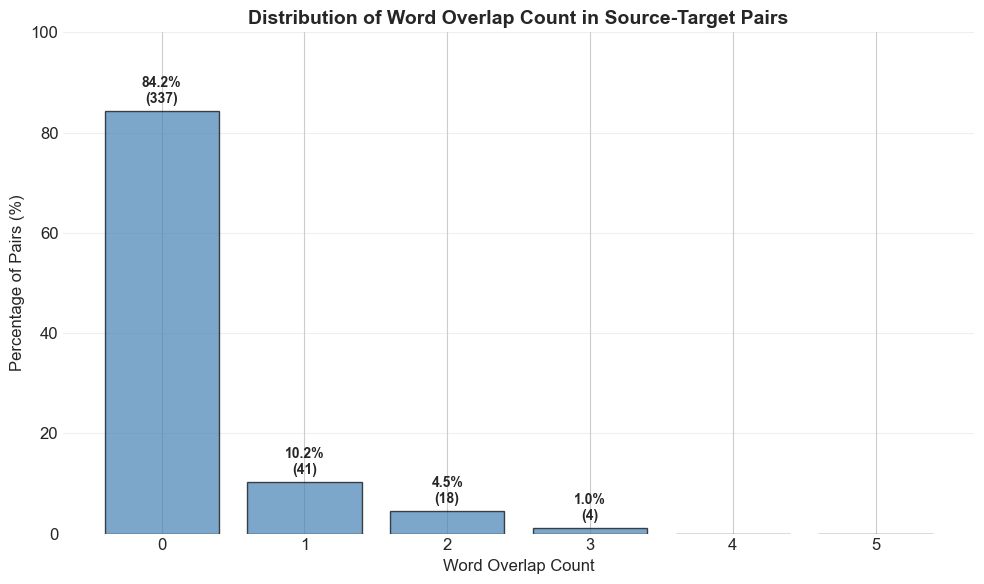


WORD OVERLAP DISTRIBUTION

Total pairs: 400
  0 overlapping words: 337 pairs (84.2%)
  1 overlapping words: 41 pairs (10.2%)
  2 overlapping words: 18 pairs (4.5%)
  3 overlapping words: 4 pairs (1.0%)


In [53]:
# Word Overlap Distribution - Simple bar chart showing percentages for 0-5 overlap counts
import matplotlib.pyplot as plt
import os

# Calculate distribution of word overlap counts (0-5)
overlap_range = range(0, 6)  # 0, 1, 2, 3, 4, 5
total_pairs = len(df_scar)

# Count pairs for each overlap value
counts = []
percentages = []
for ov in overlap_range:
    count = (df_scar['name_overlap_count'] == ov).sum()
    counts.append(count)
    percentages.append(count / total_pairs * 100)

# Create simple bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(overlap_range, percentages, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Word Overlap Count', fontsize=12)
ax.set_ylabel('Percentage of Pairs (%)', fontsize=12)
ax.set_title('Distribution of Word Overlap Count in Source-Target Pairs', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticks(list(overlap_range))
ax.set_ylim([0, 100])

# Add percentage labels on top of bars
for bar, pct, count in zip(bars, percentages, counts):
    height = bar.get_height()
    if count > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{pct:.1f}%\n({count})',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()

# Save figure
output_dir = 'results/visualizations'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'word_overlap_distribution.png'), 
            dpi=300, bbox_inches='tight')
print(f"✅ Saved figure to {output_dir}/word_overlap_distribution.png")

plt.show()

# Print summary
print("\n" + "=" * 80)
print("WORD OVERLAP DISTRIBUTION")
print("=" * 80)
print(f"\nTotal pairs: {total_pairs}")
for ov, count, pct in zip(overlap_range, counts, percentages):
    if count > 0:
        print(f"  {ov} overlapping words: {count} pairs ({pct:.1f}%)")


✅ Saved figure to results/visualizations/word_overlap_vs_rag_rank.png


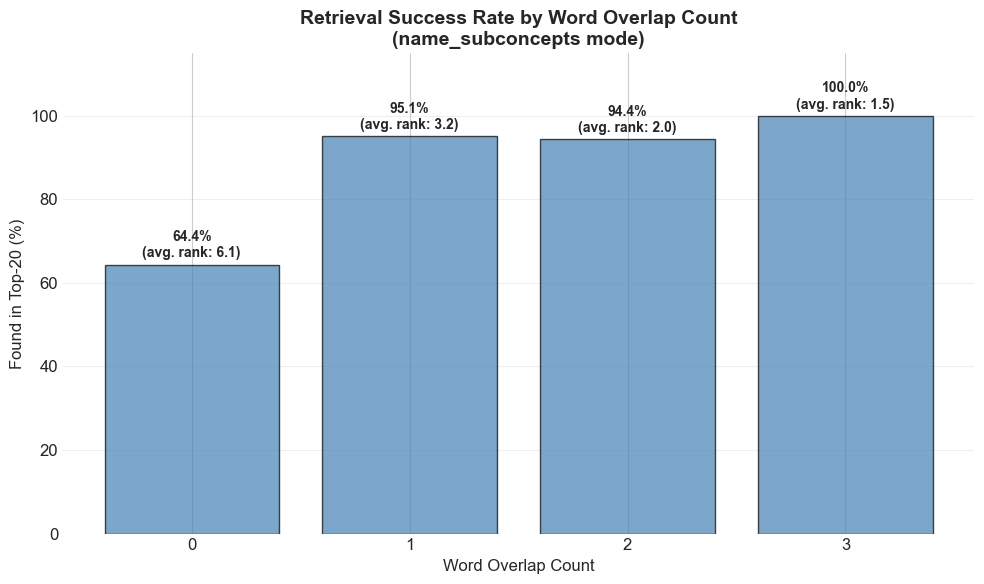


WORD OVERLAP vs RAG RETRIEVAL PERFORMANCE

Key Finding: Higher word overlap → Better retrieval (higher found %, lower rank)

By overlap count:
  0 words overlap: 64.4% found in top-20, avg rank 6.1 (n=337)
  1 words overlap: 95.1% found in top-20, avg rank 3.2 (n=41)
  2 words overlap: 94.4% found in top-20, avg rank 2.0 (n=18)
  3 words overlap: 100.0% found in top-20, avg rank 1.5 (n=4)


In [52]:
# Word Overlap vs RAG Retrieval Performance (name_properties mode)
# Shows how word overlap affects retrieval rank

import matplotlib.pyplot as plt
import os

# Focus on name_properties mode
target_mode = 'name_properties'
stats = detailed_stats[target_mode]

# Get overlap count data
overlap_df = stats['by_overlap_count'].copy()
overlap_df = overlap_df.sort_values('overlap_count')
overlap_df = overlap_df[overlap_df['total'] > 0]

# Extract data
overlap_counts = overlap_df['overlap_count'].values
found_pct = overlap_df['found_percentage'].values
avg_ranks = overlap_df['avg_rank'].values
totals = overlap_df['total'].values

# Create bar chart showing Found % by overlap count
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(overlap_counts, found_pct, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Word Overlap Count', fontsize=12)
ax.set_ylabel('Found in Top-20 (%)', fontsize=12)
ax.set_title('Retrieval Success Rate by Word Overlap Count\n(name_subconcepts mode)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticks(overlap_counts)
ax.set_ylim([0, 115])

# Add labels showing percentage and average rank
for bar, pct, rank, total in zip(bars, found_pct, avg_ranks, totals):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{pct:.1f}%\n(avg. rank: {rank:.1f})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()

# Save figure
output_dir = 'results/visualizations'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'word_overlap_vs_rag_rank.png'), 
            dpi=300, bbox_inches='tight')
print(f"✅ Saved figure to {output_dir}/word_overlap_vs_rag_rank.png")

plt.show()

# Print summary
print("\n" + "=" * 80)
print("WORD OVERLAP vs RAG RETRIEVAL PERFORMANCE")
print("=" * 80)
print(f"\nKey Finding: Higher word overlap → Better retrieval (higher found %, lower rank)")
print(f"\nBy overlap count:")
for ov, pct, rank, total in zip(overlap_counts, found_pct, avg_ranks, totals):
    print(f"  {int(ov)} words overlap: {pct:.1f}% found in top-20, avg rank {rank:.1f} (n={int(total)})")

Summary Statistics by Overlap Count:
   overlap_count  n_pairs  target_mean  source_mean  min_pair_mean
0              0      337         1.72         1.62           1.34
1              1       41         2.63         2.73           2.39
2              2       18         3.11         3.44           3.06
3              3        4         5.00         4.00           4.00



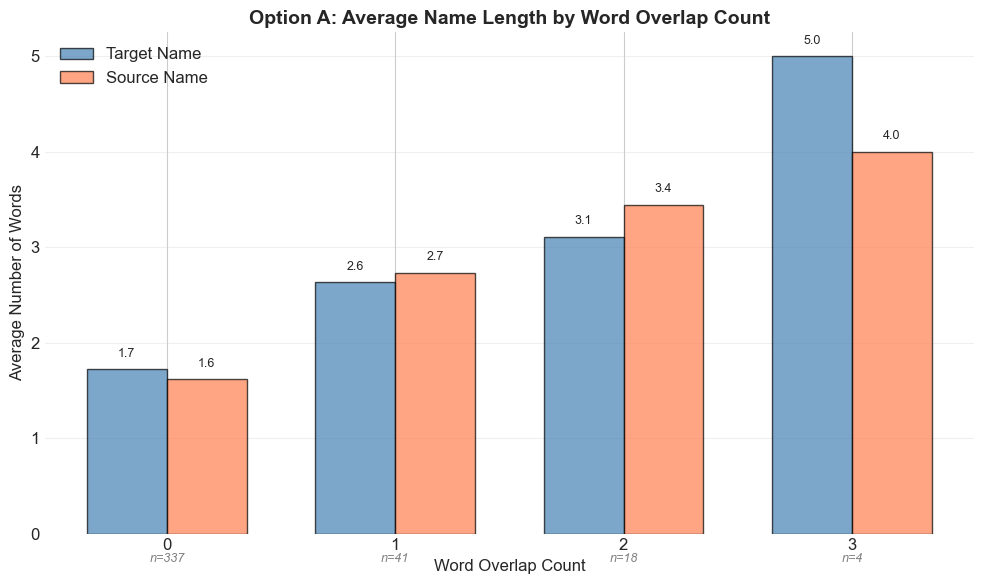

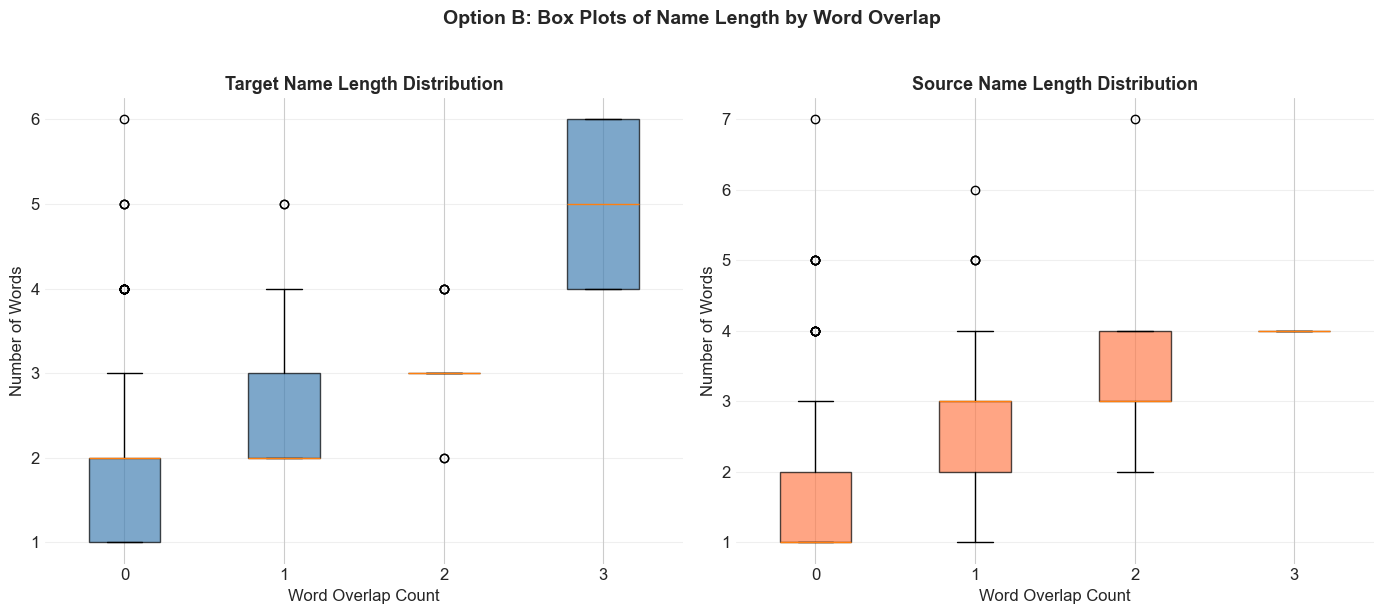

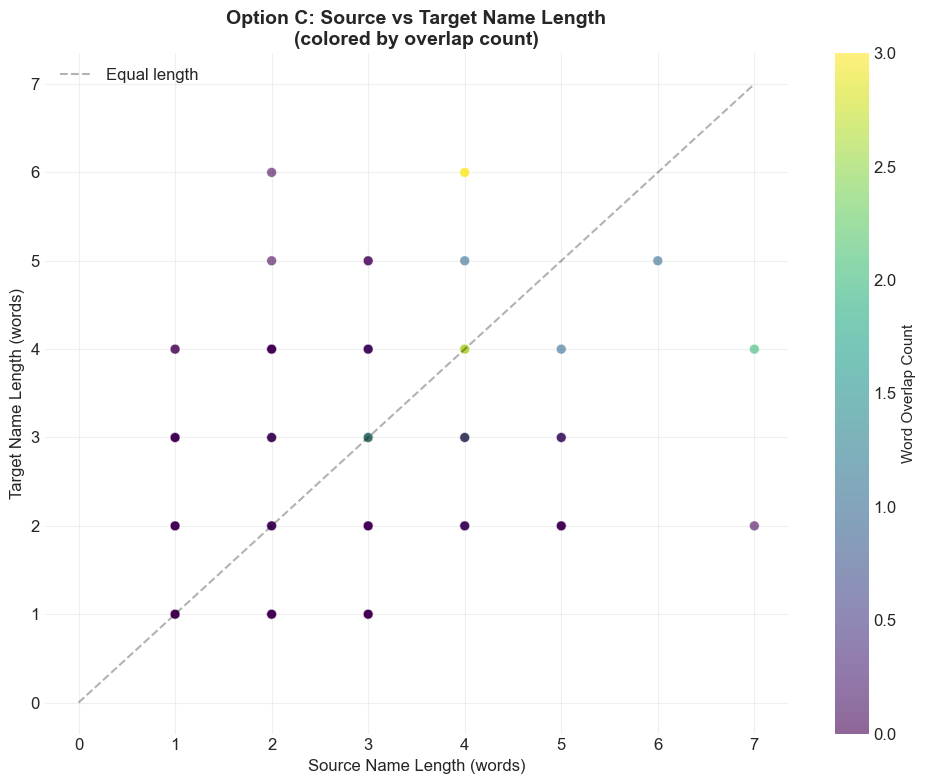

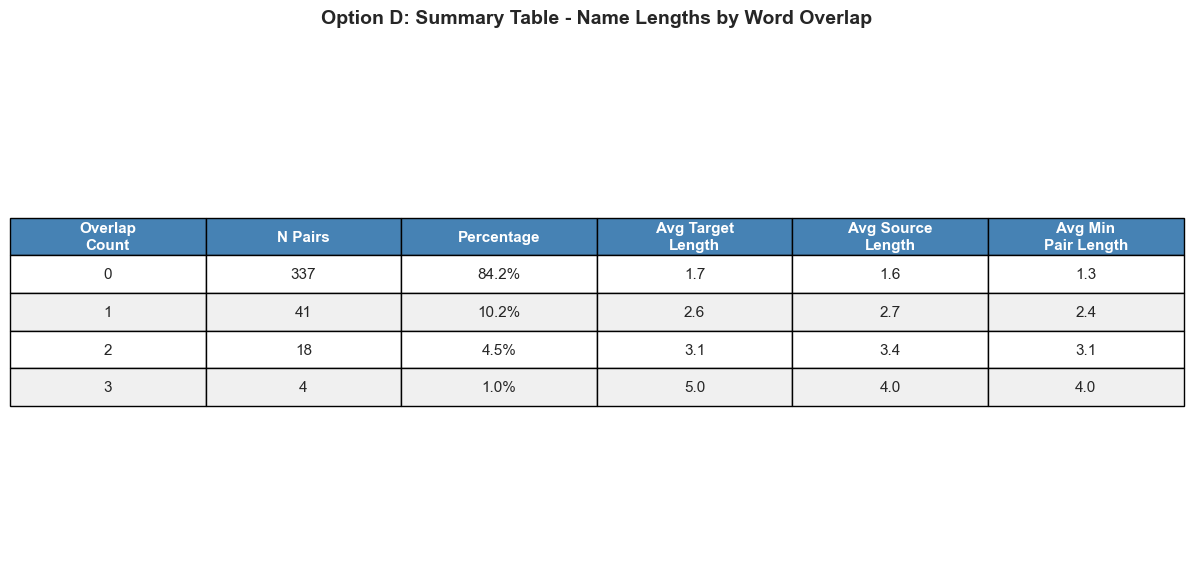


COMPARISON OF VISUALIZATION OPTIONS

Option A (Grouped Bar): Best for comparing averages at a glance
Option B (Box Plot): Best for seeing full distribution and outliers  
Option C (Scatter): Best for seeing individual pairs and patterns
Option D (Table): Best for exact numbers and quick reference

Which one do you prefer?



In [54]:
# Exploring Name Length vs Word Overlap - Multiple Visualization Options
# Let's try different approaches to see which best shows the relationship

import matplotlib.pyplot as plt
import numpy as np
import os

# Get data grouped by overlap count
overlap_groups = df_scar.groupby('name_overlap_count').agg({
    'target_word_count': ['mean', 'median', 'std', 'min', 'max', 'count'],
    'source_word_count': ['mean', 'median', 'std', 'min', 'max'],
    'min_pair_length': ['mean', 'median']
}).reset_index()

# Flatten column names
overlap_groups.columns = ['overlap_count', 
                          'target_mean', 'target_median', 'target_std', 'target_min', 'target_max', 'n_pairs',
                          'source_mean', 'source_median', 'source_std', 'source_min', 'source_max',
                          'min_pair_mean', 'min_pair_median']

print("Summary Statistics by Overlap Count:")
print(overlap_groups[['overlap_count', 'n_pairs', 'target_mean', 'source_mean', 'min_pair_mean']].round(2))
print()

# =============================================================================
# OPTION A: Grouped Bar Chart - Average word counts by overlap
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

overlap_counts = overlap_groups['overlap_count'].values
x = np.arange(len(overlap_counts))
width = 0.35

bars1 = ax.bar(x - width/2, overlap_groups['target_mean'], width, label='Target Name', 
               color='steelblue', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, overlap_groups['source_mean'], width, label='Source Name', 
               color='coral', alpha=0.7, edgecolor='black')

ax.set_xlabel('Word Overlap Count', fontsize=12)
ax.set_ylabel('Average Number of Words', fontsize=12)
ax.set_title('Option A: Average Name Length by Word Overlap Count', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(int(oc)) for oc in overlap_counts])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1, f'{height:.1f}',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1, f'{height:.1f}',
            ha='center', va='bottom', fontsize=9)

# Add sample sizes
for i, (oc, n) in enumerate(zip(overlap_counts, overlap_groups['n_pairs'])):
    ax.text(i, -0.3, f'n={int(n)}', ha='center', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.savefig('results/visualizations/option_a_grouped_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# OPTION B: Box Plot - Distribution of word counts by overlap
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Get unique overlap counts
unique_overlaps = sorted(df_scar['name_overlap_count'].unique())

# Target word count box plot
target_data = [df_scar[df_scar['name_overlap_count'] == oc]['target_word_count'].values 
               for oc in unique_overlaps]
bp1 = axes[0].boxplot(target_data, labels=[str(int(oc)) for oc in unique_overlaps], patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
axes[0].set_xlabel('Word Overlap Count', fontsize=12)
axes[0].set_ylabel('Number of Words', fontsize=12)
axes[0].set_title('Target Name Length Distribution', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Source word count box plot
source_data = [df_scar[df_scar['name_overlap_count'] == oc]['source_word_count'].values 
               for oc in unique_overlaps]
bp2 = axes[1].boxplot(source_data, labels=[str(int(oc)) for oc in unique_overlaps], patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('coral')
    patch.set_alpha(0.7)
axes[1].set_xlabel('Word Overlap Count', fontsize=12)
axes[1].set_ylabel('Number of Words', fontsize=12)
axes[1].set_title('Source Name Length Distribution', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Option B: Box Plots of Name Length by Word Overlap', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/visualizations/option_b_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# OPTION C: Scatter Plot - Source vs Target length, colored by overlap
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Create scatter plot with color by overlap count
scatter = ax.scatter(df_scar['source_word_count'], df_scar['target_word_count'], 
                     c=df_scar['name_overlap_count'], cmap='viridis', 
                     alpha=0.6, s=50, edgecolor='white', linewidth=0.5)

ax.set_xlabel('Source Name Length (words)', fontsize=12)
ax.set_ylabel('Target Name Length (words)', fontsize=12)
ax.set_title('Option C: Source vs Target Name Length\n(colored by overlap count)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Word Overlap Count', fontsize=11)

# Add diagonal line (equal length)
max_val = max(df_scar['source_word_count'].max(), df_scar['target_word_count'].max())
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Equal length')
ax.legend()

plt.tight_layout()
plt.savefig('results/visualizations/option_c_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# OPTION D: Summary Table as Heatmap-style visualization
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 6))

# Create summary data for table
table_data = []
for _, row in overlap_groups.iterrows():
    table_data.append([
        int(row['overlap_count']),
        int(row['n_pairs']),
        f"{row['n_pairs']/len(df_scar)*100:.1f}%",
        f"{row['target_mean']:.1f}",
        f"{row['source_mean']:.1f}",
        f"{row['min_pair_mean']:.1f}"
    ])

columns = ['Overlap\nCount', 'N Pairs', 'Percentage', 'Avg Target\nLength', 'Avg Source\nLength', 'Avg Min\nPair Length']

ax.axis('off')
table = ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)

# Style header
for i in range(len(columns)):
    table[(0, i)].set_facecolor('steelblue')
    table[(0, i)].set_text_props(color='white', fontweight='bold')

# Alternate row colors
for i in range(1, len(table_data) + 1):
    for j in range(len(columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')

ax.set_title('Option D: Summary Table - Name Lengths by Word Overlap', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('results/visualizations/option_d_table.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("COMPARISON OF VISUALIZATION OPTIONS")
print("=" * 80)
print("""
Option A (Grouped Bar): Best for comparing averages at a glance
Option B (Box Plot): Best for seeing full distribution and outliers  
Option C (Scatter): Best for seeing individual pairs and patterns
Option D (Table): Best for exact numbers and quick reference

Which one do you prefer?
""")